# Mesh operations with meshio++

Beyond reading and writing, meshio++ ships a set of dependency-free **mesh
operations** that run through the same C++ core (with a pure-Python fallback)
under every mesh backend. This notebook demonstrates the recent additions on the
bundled `example.msh` part, **rendering each result with PyVista** so the effect
is visible:

- **surface / skin extraction** — the boundary of a volume mesh,
- **quality metrics** — per-cell scaled Jacobian, aspect ratio, ...,
- **reordering** — RCM / space-filling-curve renumbering to cut bandwidth,
- **comparison (diff)** — is one mesh equal to another within a tolerance?,
- **format sniffing** — detect a file's format from its contents.

Each is also a CLI verb (`meshioplusplus surface|quality|reorder|diff ...`).

In [1]:
import os
import tempfile
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv

import meshioplusplus as mp

# Head-less, static rendering (no display / live server needed).
pv.OFF_SCREEN = True
pv.set_jupyter_backend('static')


def to_pyvista(mesh):
    """meshio++ Mesh -> pyvista grid via a temporary .vtu."""
    with tempfile.NamedTemporaryFile(suffix='.vtu', delete=False) as f:
        tmp = f.name
    try:
        mp.write(tmp, mesh)
        return pv.read(tmp)
    finally:
        os.unlink(tmp)


# Renders that the documentation embeds are written here as well as shown, so
# doc/ and the notebooks can never drift apart: regenerating the notebook
# regenerates the figures the docs point at.
DOC_IMAGES = os.path.join(os.path.dirname(os.path.dirname(os.getcwd())), 'doc', 'public', 'images')


def show(img, title=None, figsize=(9, 6), save=None):
    """Embed a rendered RGB screenshot as a static image.

    When `save` is given, also write the raw render to doc/images/<save>.png
    for the documentation to embed.
    """
    if save:
        try:
            os.makedirs(DOC_IMAGES, exist_ok=True)
            plt.imsave(os.path.join(DOC_IMAGES, save + '.png'), img)
        except Exception as exc:  # pragma: no cover - read-only checkout
            print('doc image not written:', exc)
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.axis('off')
    if title:
        plt.title(title)
    plt.tight_layout()
    plt.show()


def render(mesh, title, scalars=None, cmap='viridis', clim=None, color='#2ec4b6',
          save=None):
    """Render a meshio++ mesh, optionally coloured by a data array."""
    grid = to_pyvista(mesh)
    try:
        pl = pv.Plotter(off_screen=True, window_size=(1000, 720))
        if scalars is not None:
            pl.add_mesh(grid, scalars=scalars, cmap=cmap, clim=clim,
                        show_edges=False, scalar_bar_args={'title': scalars})
        else:
            pl.add_mesh(grid, color=color, show_edges=True,
                        edge_color='#1f4e79', line_width=0.2)
        pl.camera_position = 'iso'
        pl.add_axes()
        img = pl.screenshot(return_img=True)
        pl.close()
        show(img, title, save=save)
    except Exception as exc:  # pragma: no cover - head-less GL fallback
        print('PyVista render skipped:', exc)


def save_fig(name):
    """Write the current matplotlib figure to doc/public/images/<name>.png.

    For the plain-matplotlib demo cells (histograms, scatter plots, bar
    charts) that don't go through `render`/`show`'s RGB-array path.
    """
    try:
        os.makedirs(DOC_IMAGES, exist_ok=True)
        plt.savefig(os.path.join(DOC_IMAGES, name + '.png'), dpi=110, bbox_inches='tight')
    except Exception as exc:  # pragma: no cover - read-only checkout
        print('doc image not written:', exc)

## Read the mesh

In [2]:
EXAMPLE = os.path.join(os.path.dirname(os.getcwd()), 'example.msh')
if not os.path.exists(EXAMPLE):
    EXAMPLE = os.path.join('..', 'example.msh')  # when run from example/python/ with a different cwd

mesh = mp.read(EXAMPLE)
totals = Counter()
for cb in mesh.cells:
    totals[cb.type] += len(cb.data)
print('backend      :', mp._core.__mesh_backend__)
print('points       :', len(mesh.points))
print('cells by type:', dict(totals))


backend      : meshio
points       : 52282
cells by type: {'vertex': 234, 'line': 4169, 'triangle': 58394, 'tetra': 235014}


## Surface / skin extraction

`extract_surface` returns the boundary of the highest-dimension cells (volume →
boundary faces); `extract_skin` is the volume-only variant. We render the
extracted boundary surface.

surface:

 [('triangle', 58394)]
skin   : [('triangle', 58394)]


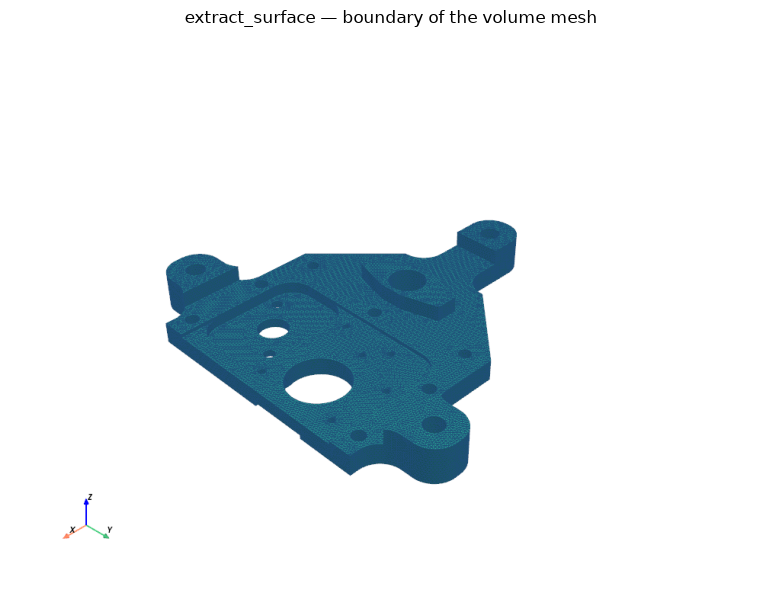

In [3]:
surface = mp.extract_surface(mesh)
skin = mp.extract_skin(mesh, linearize=True)
print('surface:', [(cb.type, len(cb.data)) for cb in surface.cells])
print('skin   :', [(cb.type, len(cb.data)) for cb in skin.cells])
render(surface, 'extract_surface — boundary of the volume mesh',
       save='extract_surface')

## Quality metrics

`compute_quality` scores every cell on a set of geometric metrics (and flags
inverted / degenerate cells); `attach_quality` writes them back as `cell_data`.
Below: the distribution of the scaled Jacobian over the whole part, then the
**boundary coloured by its per-triangle scaled Jacobian** (1 = ideal).

cells scored : 297811
inverted     : 0
quality:scaled_jacobian  min=0.011 mean=0.463 max=1.000
quality:aspect_ratio     min=1.000 mean=1.538 max=1439.572


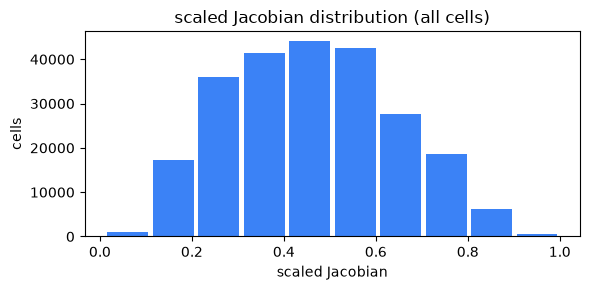

In [4]:
report = mp.compute_quality(mesh)
print('cells scored :', report['num_cells'])
print('inverted     :', report['num_inverted'])
for name in ('quality:scaled_jacobian', 'quality:aspect_ratio'):
    s = report['metrics'][name]
    print(f"{name:24s} min={s['min']:.3f} mean={s['mean']:.3f} max={s['max']:.3f}")

sj = report['metrics']['quality:scaled_jacobian']
fig, ax = plt.subplots(figsize=(6, 3))
edges = np.linspace(sj['min'], sj['max'], len(sj['histogram']) + 1)
ax.bar(0.5 * (edges[:-1] + edges[1:]), sj['histogram'],
       width=(edges[1] - edges[0]) * 0.9, color='#3b82f6')
ax.set(title='scaled Jacobian distribution (all cells)',
       xlabel='scaled Jacobian', ylabel='cells')
plt.tight_layout()
save_fig('quality_histogram')
plt.show()

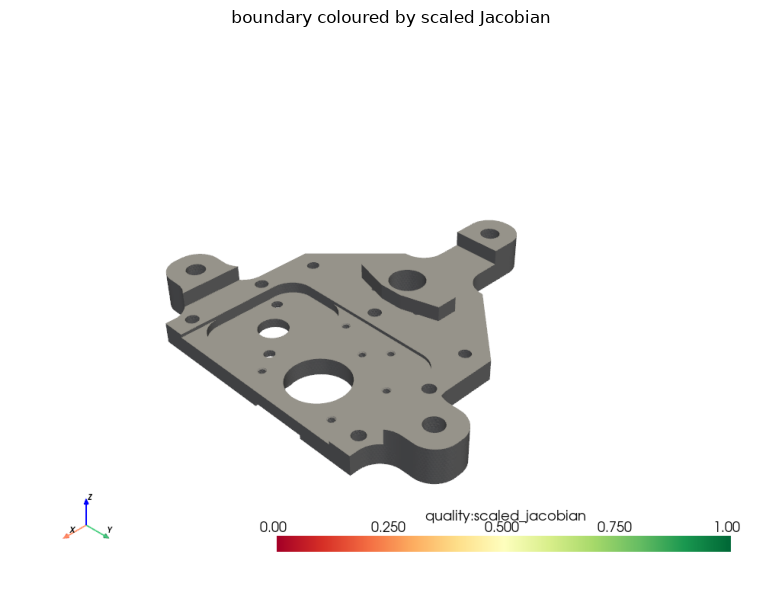

In [5]:
# colour the boundary triangles by their own scaled Jacobian
surf_q = mp.attach_quality(surface)
render(surf_q, 'boundary coloured by scaled Jacobian',
       scalars='quality:scaled_jacobian', cmap='RdYlGn', clim=(0.0, 1.0),
       save='quality_boundary')

## Reordering / renumbering

`reorder` renumbers nodes and elements (Reverse Cuthill–McKee by default, or the
Morton / Hilbert space-filling curves) as a *pure permutation*.
`compute_bandwidth` measures the connectivity bandwidth before and after — RCM
collapses it dramatically.

*(This gmsh part carries a `gmsh:bounding_entities` cell_set of geometry ids;
we clear the side-channel sets so the demo focuses on the geometry.)*

In [6]:
plain = mp.read(EXAMPLE)
plain.cell_sets = {}
plain.point_sets = {}

before = mp.compute_bandwidth(plain)
for method in ('rcm', 'morton', 'hilbert'):
    out = mp.reorder(plain, method=method)
    print(f'{method:8s}: bandwidth {before} -> {mp.compute_bandwidth(out)}')


rcm     : bandwidth 50857 -> 1229
morton  : bandwidth 50857 -> 41980
hilbert : bandwidth 50857 -> 46623


The bandwidth is the largest node-index gap within any cell. Plotting every
connectivity **edge as a point `(i, j)`** shows it geometrically: RCM pulls all
the edges tight against the diagonal (small bandwidth), the original numbering
scatters them across the whole matrix.

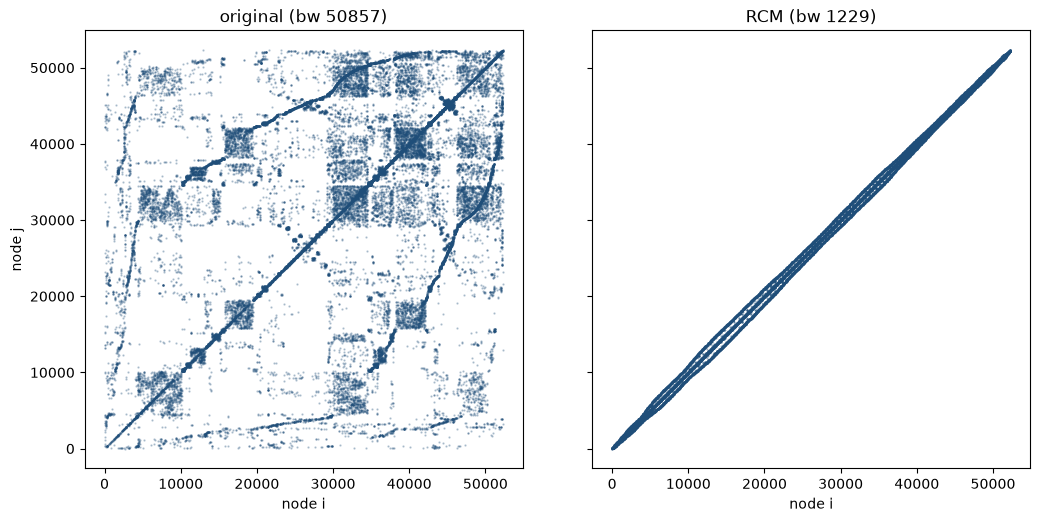

In [7]:
_, node_perm, _ = mp.reorder(plain, method='rcm', return_permutation=True)
tet = np.asarray([cb.data for cb in plain.cells if cb.type == 'tetra'][0])
pairs = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
edges = np.vstack([tet[:, [a, b]] for a, b in pairs])
rng = np.random.default_rng(0)
edges = edges[rng.choice(len(edges), size=min(40000, len(edges)), replace=False)]
after = node_perm[edges]

fig, axes = plt.subplots(1, 2, figsize=(11, 5.2), sharex=True, sharey=True)
for ax, e, ttl in ((axes[0], edges, f'original (bw {before})'),
                   (axes[1], after, f'RCM (bw {mp.compute_bandwidth(mp.reorder(plain)) })')):
    ax.scatter(e[:, 0], e[:, 1], s=0.4, alpha=0.3, color='#1f4e79')
    ax.set(title=ttl, xlabel='node i', aspect='equal')
axes[0].set_ylabel('node j')
plt.tight_layout()
save_fig('reorder_bandwidth')
plt.show()

## Comparison (diff)

`meshes_equal` is the boolean helper for regression tests; `diff` returns a
structured report with an overall verdict. First the canonical CI pattern —
**write to another format, read it back, assert equal within tolerance**:

In [8]:
tmp = os.path.join(tempfile.mkdtemp(), 'surface.vtu')
mp.write(tmp, surface)
roundtrip = mp.read(tmp)
print('round-trip equal :', mp.meshes_equal(surface, roundtrip, atol=1e-10))

round-trip equal : True


Now a **localised deformation**: we push a bump into the surface and let `diff`
find it. The report pinpoints the worst-offending point; rendering the per-point
error shows exactly *where* the two meshes disagree.

verdict          : different
points exceeding : 25843
worst point index: 36371 | max abs error: 4.960e-02


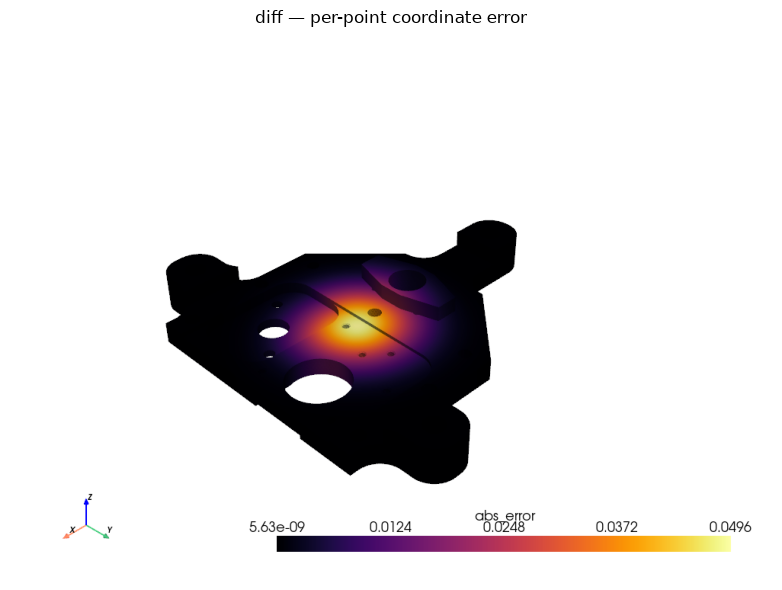

In [9]:
base = np.asarray(surface.points, dtype=float)
centre = base.mean(axis=0)
d = np.linalg.norm(base - centre, axis=1)
bump = 0.05 * np.exp(-((d / (0.25 * d.max())) ** 2))
moved = base.copy()
moved[:, 2] += bump
deformed = mp.Mesh(moved, surface.cells)

rep = mp.diff(surface, deformed, atol=1e-6, rtol=0.0)
print('verdict          :', rep['verdict'])
print('points exceeding :', rep['points']['num_exceeding'])
print('worst point index:', rep['points']['worst_index'],
      '| max abs error:', f"{rep['points']['max_abs_error']:.3e}")

err = np.linalg.norm(moved - base, axis=1)
vis = mp.Mesh(base, surface.cells, point_data={'abs_error': err})
render(vis, 'diff — per-point coordinate error', scalars='abs_error', cmap='inferno',
       save='diff_error')

`diff` also has an **unordered** mode that matches nodes by spatial proximity,
so a mesh whose nodes were merely *renumbered* still compares equal. Here we take
the surface geometry and shuffle its node numbering (permute the points and remap
the connectivity, keeping the cells in place):

In [10]:
geo = mp.Mesh(base, surface.cells)             # geometry only, no data
conn = np.asarray(geo.cells[0].data)
perm = np.random.default_rng(0).permutation(len(base))   # old -> new node id
inv = np.empty(len(base), dtype=np.int64)
inv[perm] = np.arange(len(base))
shuffled = mp.Mesh(base[inv], [('triangle', perm[conn])])

print('ordered   verdict:', mp.diff(geo, shuffled)['verdict'])
print('unordered verdict:', mp.diff(geo, shuffled, unordered=True)['verdict'])

ordered   verdict: different
unordered verdict: identical


## Format sniffing

`sniff_format` detects a file's format from its leading bytes (used as a
read-side fallback when the extension is unknown).

In [11]:
print('sniffed format of the .vtu we wrote:', mp.sniff_format(tmp))

sniffed format of the .vtu we wrote: vtu


## Affine transform

`transform` moves the points (translate / scale / rotate / matrix / unit-scale)
while carrying connectivity and data through. Here we rotate the boundary
surface 45° about the x-axis, colouring by each point's *original* height so the
reorientation is visible.

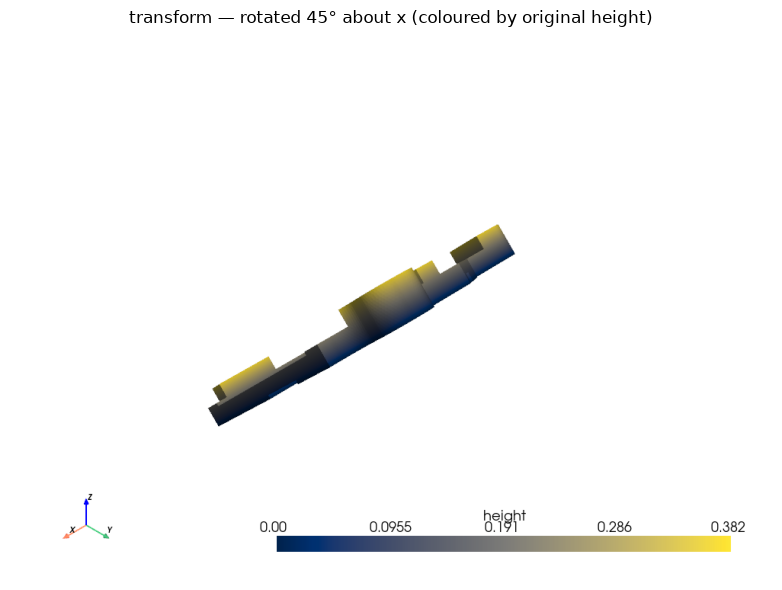

In [12]:
surf_h = mp.Mesh(np.asarray(surface.points), surface.cells)
surf_h.point_data['height'] = np.asarray(surface.points)[:, 2].astype(float).copy()
rotated = mp.transform(surf_h, rotate=('x', 45))
render(rotated, 'transform — rotated 45° about x (coloured by original height)',
       scalars='height', cmap='cividis', save='transform_rotate')

## Clean (weld / prune / de-dup)

We build a deliberately messy mesh by duplicating every point and cell of the
surface, then `clean(..., weld=True)` fuses the coincident points (halving the
point count) and drops the resulting duplicate cells.

points: 58302 -> 29151 (welded 29151, duplicate cells dropped 58394)


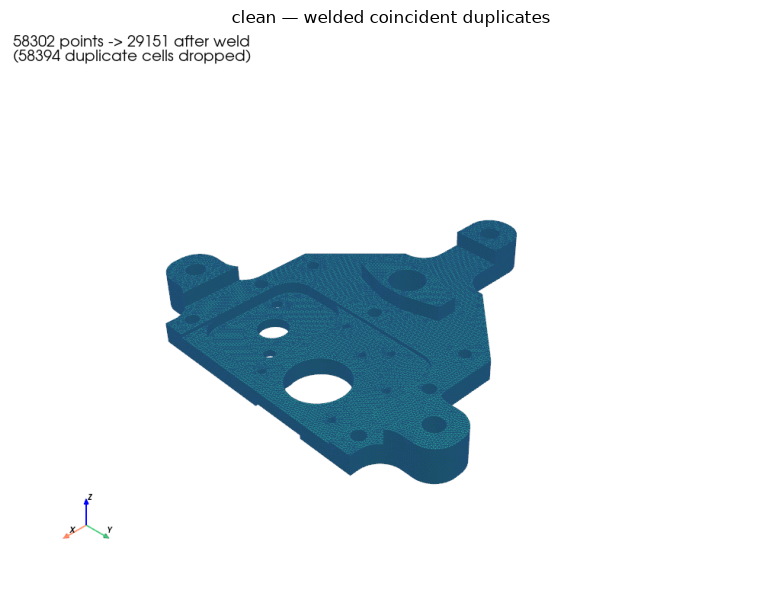

In [13]:
pts = np.asarray(surface.points, dtype=float)
dup_pts = np.vstack([pts, pts])
dup_cells = [(cb.type, np.vstack([np.asarray(cb.data), np.asarray(cb.data) + len(pts)]))
             for cb in surface.cells]
dirty = mp.Mesh(dup_pts, dup_cells)
cleaned, rep = mp.clean(dirty, weld=True, atol=1e-8, return_report=True)
print(f"points: {len(dirty.points)} -> {len(cleaned.points)} "
      f"(welded {rep['points_welded']}, duplicate cells dropped {rep['cells_dropped_duplicate']})")
# The weld is geometrically invisible here -- the duplicate sits exactly on
# top of the original -- so the point/cell counts are what tell the story;
# annotate them directly on the render rather than showing two identical shapes.
try:
    pl = pv.Plotter(off_screen=True, window_size=(1000, 720))
    pl.add_mesh(to_pyvista(cleaned), color='#2ec4b6', show_edges=True,
                edge_color='#1f4e79', line_width=0.2)
    pl.add_text(f"{len(dirty.points)} points -> {len(cleaned.points)} after weld\n"
                f"({rep['cells_dropped_duplicate']} duplicate cells dropped)", font_size=11)
    pl.camera_position = 'iso'
    pl.add_axes()
    img = pl.screenshot(return_img=True)
    pl.close()
    show(img, 'clean — welded coincident duplicates', save='clean_weld')
except Exception as exc:  # pragma: no cover - head-less GL fallback
    print('PyVista render skipped:', exc)

## Crop (bounding box / half-space)

`crop` keeps the part of a mesh inside a region. Here we keep the half of the
surface below the mid-plane in x with an axis-aligned bounding box.

kept cells: [('triangle', 17122)]


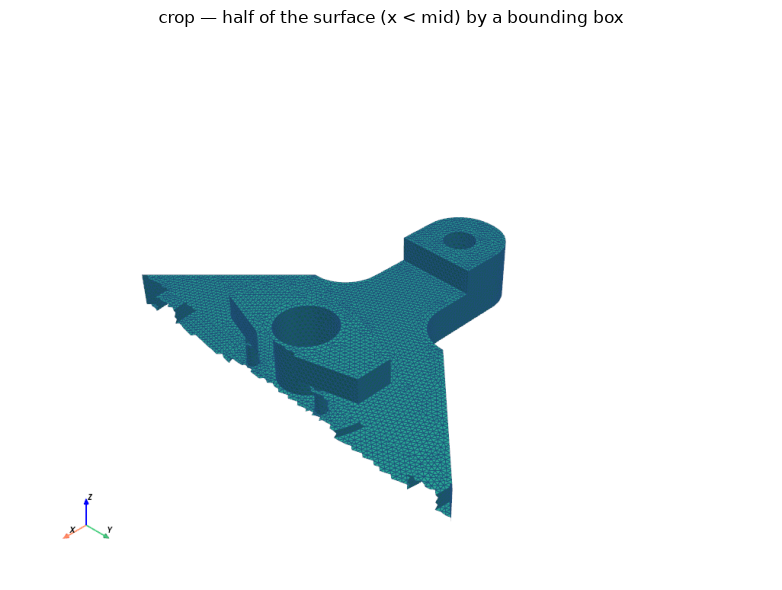

In [14]:
lo = pts.min(axis=0)
hi = pts.max(axis=0)
mid = 0.5 * (lo + hi)
cropped = mp.crop(surface, bbox=[lo[0], lo[1], lo[2], mid[0], hi[1], hi[2]], mode='all')
print('kept cells:', [(cb.type, len(cb.data)) for cb in cropped.cells])
render(cropped, 'crop — half of the surface (x < mid) by a bounding box',
       save='crop_bbox')

## Named regions

A **region** is a named group of entities — what gmsh calls a physical group,
Abaqus an `*NSET`/`*ELSET`/`*SURFACE`, Exodus a block or set. Since v8.1.0 they
are first-class in the C++ core, so they survive conversion and every operation
either remaps them or says it dropped them.

Three kinds: `point` (point indices), `cell` (**global**, block-major cell
indices) and `side` — groups of cell *facets*, which had no representation
anywhere in meshio++ before. `mesh.point_sets` / `mesh.cell_sets` still work
exactly as they did; they are views over the same regions.

Below we tag the surface's cells into two named groups by their x position, then
crop — and colour by group membership on both sides to see the regions follow
the cells they name. See [the regions documentation](https://loumalouomega.github.io/meshioplusplus/regions).

regions: [('left', 'cell', 17355), ('right', 'cell', 41039)]


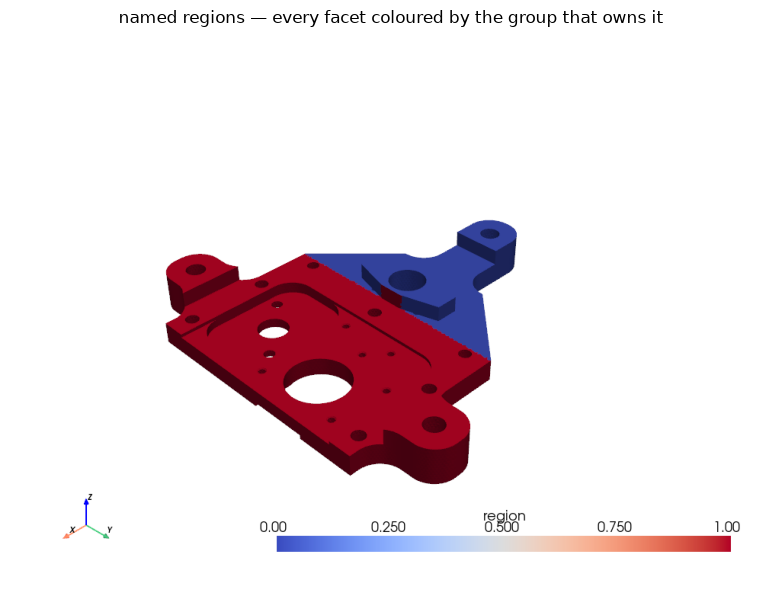

In [15]:
# Tag the surface's facets into two named groups, by which side of the
# mid-plane their centroid falls on. `cell_sets` is the familiar spelling; it
# writes through to a `cell` region on `surface.regions`.
surf_pts = np.asarray(surface.points, dtype=float)
centroid_x = np.concatenate([
    surf_pts[np.asarray(cb.data)][:, :, 0].mean(axis=1) for cb in surface.cells
])

offsets = np.cumsum([0] + [len(cb.data) for cb in surface.cells])
left_blocks, right_blocks = [], []
for b in range(len(surface.cells)):
    local = centroid_x[offsets[b]:offsets[b + 1]]
    left_blocks.append(np.nonzero(local < mid[0])[0])
    right_blocks.append(np.nonzero(local >= mid[0])[0])

tagged = surface.copy()
tagged.cell_sets = {'left': left_blocks, 'right': right_blocks}
print('regions:', [(r.name, r.kind, len(r.entries)) for r in tagged.regions])


def colour_by_region(mesh, names):
    """A per-cell array numbering each cell by which named region owns it."""
    total = sum(len(cb.data) for cb in mesh.cells)
    owner = np.full(total, -1, dtype=np.int64)
    for i, name in enumerate(names):
        blocks = mesh.cell_sets.get(name)
        if blocks is None:
            continue
        base = 0
        for b, cb in enumerate(mesh.cells):
            if b < len(blocks) and blocks[b] is not None:
                owner[base + np.asarray(blocks[b], dtype=np.int64)] = i
            base += len(cb.data)
    out = mesh.copy()
    base = 0
    per_block = []
    for cb in mesh.cells:
        per_block.append(owner[base:base + len(cb.data)].astype(np.float64))
        base += len(cb.data)
    out.cell_data['region'] = per_block
    return out


render(colour_by_region(tagged, ['left', 'right']),
       'named regions — every facet coloured by the group that owns it',
       scalars='region', cmap='coolwarm', save='regions_before_crop')

left  :  17355 cells ->  17122 after the crop
right :  41039 cells ->      0 after the crop


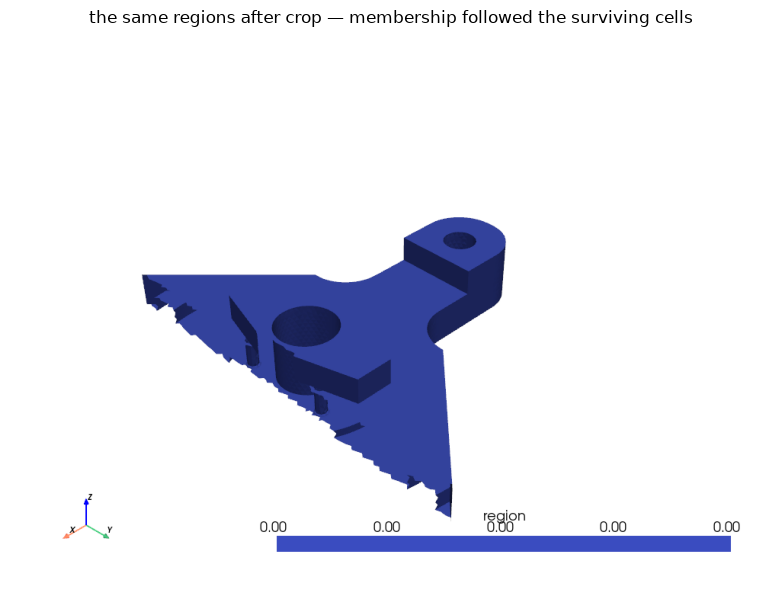

In [16]:
# Crop away the right half. The `left` region's cells survive and are renumbered
# onto the cropped mesh; `right` loses every member but is still carried, as an
# empty group -- the *name* is information the mesh was told about.
cropped_tagged = mp.crop(
    tagged, bbox=[lo[0], lo[1], lo[2], mid[0], hi[1], hi[2]], mode='all')

for name in ('left', 'right'):
    kept = sum(len(b) for b in cropped_tagged.cell_sets[name])
    before = sum(len(b) for b in tagged.cell_sets[name])
    print(f'{name:6s}: {before:6d} cells -> {kept:6d} after the crop')

render(colour_by_region(cropped_tagged, ['left', 'right']),
       'the same regions after crop — membership followed the surviving cells',
       scalars='region', cmap='coolwarm', save='regions_after_crop')

In [17]:
# Side regions: groups of cell *facets*, the kind that had no representation in
# meshio++ before. They ride on `mesh.regions` only -- there is no `*_sets`
# spelling for them -- and Abaqus is the Phase-1 format that can write one.
solid = mp.read(EXAMPLE)
solid_tets = mp.Mesh(solid.points,
                     [(cb.type, cb.data) for cb in solid.cells if cb.type == 'tetra'])
solid_tets.regions.append(
    mp.Region('wall', 'side', [[0, 1], [1, 3], [2, 0]], dim=2))

with tempfile.NamedTemporaryFile(suffix='.inp', delete=False) as f:
    inp = f.name
try:
    mp.write(inp, solid_tets)
    back = mp.read(inp)
    for r in back.regions:
        print(f'{r.name:6s} kind={r.kind:5s} entries={r.entries.tolist()}')
finally:
    os.unlink(inp)

wall   kind=side  entries=[[0, 1], [1, 3], [2, 0]]


## Merge / weld

`merge` combines several meshes into one. By default it simply concatenates
them; with `weld=True` it fuses points that coincide within a tolerance. Merging
a mesh with an exact copy of itself makes the difference unmistakable — the
welded result has exactly the original point count back. `source_tag=True`
records which input each cell came from, which is what the render colours by.


inputs       : 29151 + 29151 = 58302 points
concatenated : 58302 points
welded       : 29151 points (29151 fused)


meshio warning [merge.cpp:342] merge: dropping partial point_data 'gmsh:dim_tags' (intersection policy)
meshio warning [merge.cpp:342] merge: dropping partial point_data 'gmsh:dim_tags' (intersection policy)


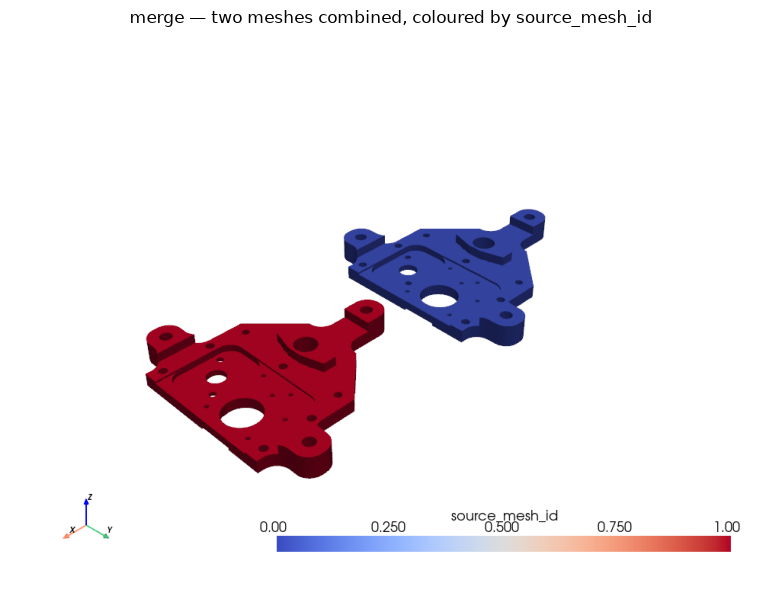

In [18]:
# Merge the surface with an exact copy of itself. Concatenating doubles the
# point count; welding recognises every point as coincident and fuses it back.
dup = mp.Mesh(pts.copy(), surface.cells)

plain = mp.merge([surface, dup], source_tag=True)
welded = mp.merge([surface, dup], weld=True, atol=1e-8, source_tag=True)

print('inputs       :', len(surface.points), '+', len(dup.points),
      '=', len(surface.points) + len(dup.points), 'points')
print('concatenated :', len(plain.points), 'points')
print('welded       :', len(welded.points), 'points',
      f'({len(plain.points) - len(welded.points)} fused)')

# Side by side, a genuinely disjoint merge: the surface plus a shifted copy,
# coloured by which input each cell came from.
span = hi[0] - lo[0]
shifted = mp.transform(surface, translate=(1.15 * span, 0.0, 0.0))
pair = mp.merge([surface, shifted], source_tag=True)
render(pair, 'merge — two meshes combined, coloured by source_mesh_id',
       scalars='source_mesh_id', cmap='coolwarm', save='merge_sources')


## Split (partition into pieces)

`split` partitions a mesh by type, connected component, or region. We tag each
surface cell left/right of the mid-plane and split by that region, then recombine
the pieces with `merge(source_tag=True)` to colour each cell by its piece.

pieces: {'1': 41039, '0': 17355}


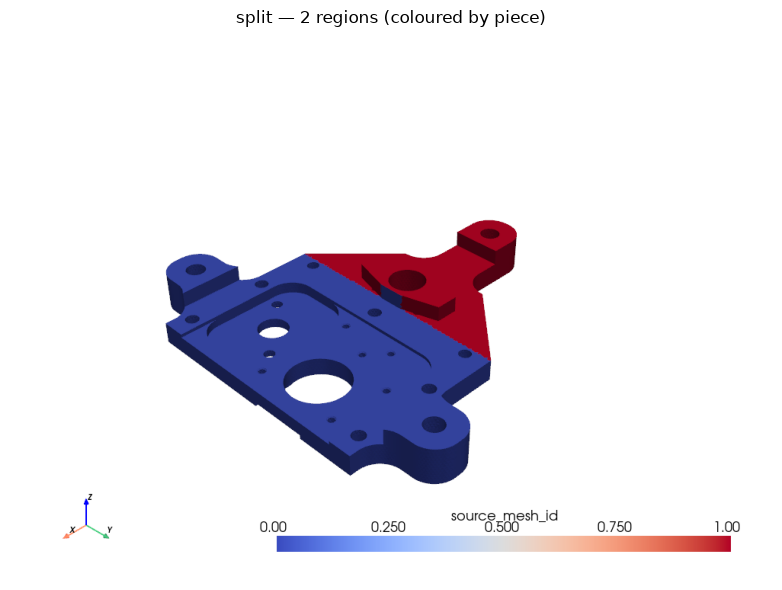

In [19]:
surf_r = mp.Mesh(pts, surface.cells)
region_blocks = []
for cb in surface.cells:
    centroid_x = pts[np.asarray(cb.data)][:, :, 0].mean(axis=1)
    region_blocks.append((centroid_x > mid[0]).astype(np.int64))
surf_r.cell_data['region'] = region_blocks
pieces = mp.split(surf_r, by='region', tag='region')
print('pieces:', {k: sum(len(cb.data) for cb in v.cells) for k, v in pieces.items()})
tagged = mp.merge(list(pieces.values()), source_tag=True)
render(tagged, f'split — {len(pieces)} regions (coloured by piece)',
       scalars='source_mesh_id', cmap='coolwarm', save='split_regions')

## Geometric statistics

`compute_stats` returns geometric measures — the geometric complement to the
topological `info`. Below we print the bounding box / centroid / volume and plot
the per-cell-type counts.

bbox     : (-3.505, -3.185, 0.0) -> (0.0, 0.625, 0.382)
centroid : (-1.346, -1.263, 0.139)
area     : 41.681
volume   : signed 1.2299 | unsigned 1.2299 | inverted 0


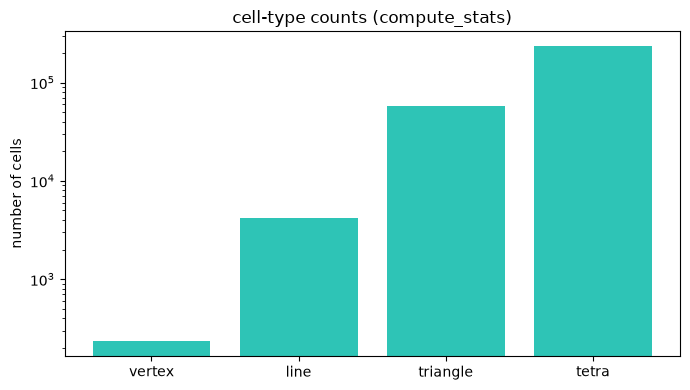

In [20]:
s = mp.compute_stats(mesh)
print('bbox     :', tuple(round(v, 3) for v in s['bbox_min']), '->',
      tuple(round(v, 3) for v in s['bbox_max']))
print('centroid :', tuple(round(v, 3) for v in s['centroid']))
print('area     :', round(s['total_area'], 4))
print('volume   : signed', round(s['signed_volume'], 4),
      '| unsigned', round(s['unsigned_volume'], 4), '| inverted', s['num_inverted'])
counts = s['cell_type_counts']
plt.figure(figsize=(7, 4))
plt.bar(list(counts), list(counts.values()), color='#2ec4b6')
plt.ylabel('number of cells')
plt.yscale('log')
plt.title('cell-type counts (compute_stats)')
plt.tight_layout()
save_fig('stats_celltypes')
plt.show()

## Cell conversion (linearize / simplexify / elevate)

`convert_cells` rewrites which cell *types* a mesh is built from, leaving the
object it describes intact. Below we take a small hexahedral block and
**simplexify** it: each hexahedron becomes 6 tetrahedra that reuse the parent's
own corner nodes, so no points are added, the volume is conserved exactly, and
every emitted tetrahedron is positively oriented.


before:  27 hexahedron  | points  64 | volume 27.000000
after : 162 tetra       | points  64 | volume 27.000000
inverted cells after simplexify: 0


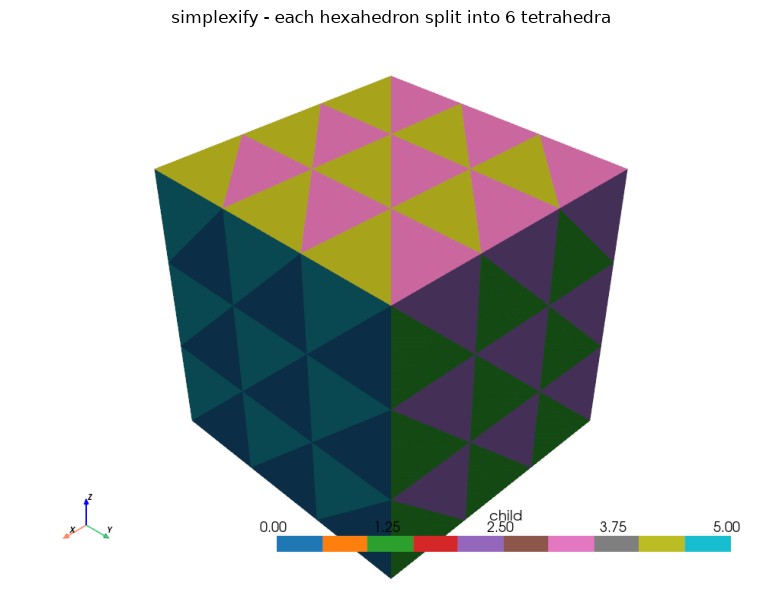

In [21]:
# A 3x3x3 block of hexahedra -- small enough that the wireframe stays readable.
n = 3
gx, gy, gz = np.meshgrid(*[np.arange(n + 1, dtype=float)] * 3, indexing='ij')
hex_pts = np.column_stack([gx.ravel(), gy.ravel(), gz.ravel()])
pid = lambda i, j, k: (i * (n + 1) + j) * (n + 1) + k
hex_conn = np.array([
    [pid(i, j, k), pid(i + 1, j, k), pid(i + 1, j + 1, k), pid(i, j + 1, k),
     pid(i, j, k + 1), pid(i + 1, j, k + 1), pid(i + 1, j + 1, k + 1), pid(i, j + 1, k + 1)]
    for i in range(n) for j in range(n) for k in range(n)
])
hexes = mp.Mesh(hex_pts, [('hexahedron', hex_conn)])

tets = mp.convert_cells(hexes, mode='simplexify')

before, after = mp.compute_stats(hexes), mp.compute_stats(tets)
print(f"before: {before['num_cells']:3d} {hexes.cells[0].type:<11s}"
      f" | points {len(hexes.points):3d} | volume {before['unsigned_volume']:.6f}")
print(f"after : {after['num_cells']:3d} {tets.cells[0].type:<11s}"
      f" | points {len(tets.points):3d} | volume {after['unsigned_volume']:.6f}")
print('inverted cells after simplexify:', after['num_inverted'])

# Colour each tetrahedron by which of its parent hexahedron's 6 children it is,
# so the decomposition template itself is visible.
tagged = mp.convert_cells(hexes, mode='simplexify', record_parent_ids=True)
parent = np.asarray(tagged.cell_data['convert:parent_cell'][0])
tagged.cell_data['child'] = [np.arange(len(parent)) % 6]
render(tagged, 'simplexify - each hexahedron split into 6 tetrahedra',
       scalars='child', cmap='tab10', save='convert_cells_simplexify')


In [22]:
# elevate does the opposite: linear cells gain a node per unique edge.
quad = mp.convert_cells(hexes, mode='elevate')
print(f"elevate    : {hexes.cells[0].type} -> {quad.cells[0].type}"
      f" | points {len(hexes.points)} -> {len(quad.points)}")

# and linearize brings it back, pruning the mid-edge nodes it just added.
back = mp.convert_cells(quad, mode='linearize')
print(f"linearize  : {quad.cells[0].type} -> {back.cells[0].type}"
      f" | points {len(quad.points)} -> {len(back.points)}")
print('round-trip recovers the original mesh:', mp.meshes_equal(hexes, back))


elevate    : hexahedron -> hexahedron20 | points 64 -> 208
linearize  : hexahedron20 -> hexahedron | points 208 -> 64
round-trip recovers the original mesh: True


## Uniform refinement

`refine` is the resolution-*increasing* counterpart to `convert_cells`: it
subdivides every cell into congruent children of the **same** type — a triangle
or quad into 4, a tetrahedron, wedge or hexahedron into 8 — inserting nodes at
the midpoints of the parent's edges, quad faces and (hexahedron only) body.

Those mid-entity nodes are **shared** between every cell touching them, so the
refined mesh has no hanging nodes, and `point_data` is interpolated onto them as
the mean of the entity's corners. Below we refine a coarse hexahedral block once
and compare the two side by side.


coarse:   8 cells |  27 points | volume 8.000000
fine  :  64 cells | 125 points | volume 8.000000
newly inverted cells: 0
points: 125 (a conforming 5x5x5 lattice) vs 216 if every cell kept its own copy
max interpolation error on a linear field: 0.00e+00


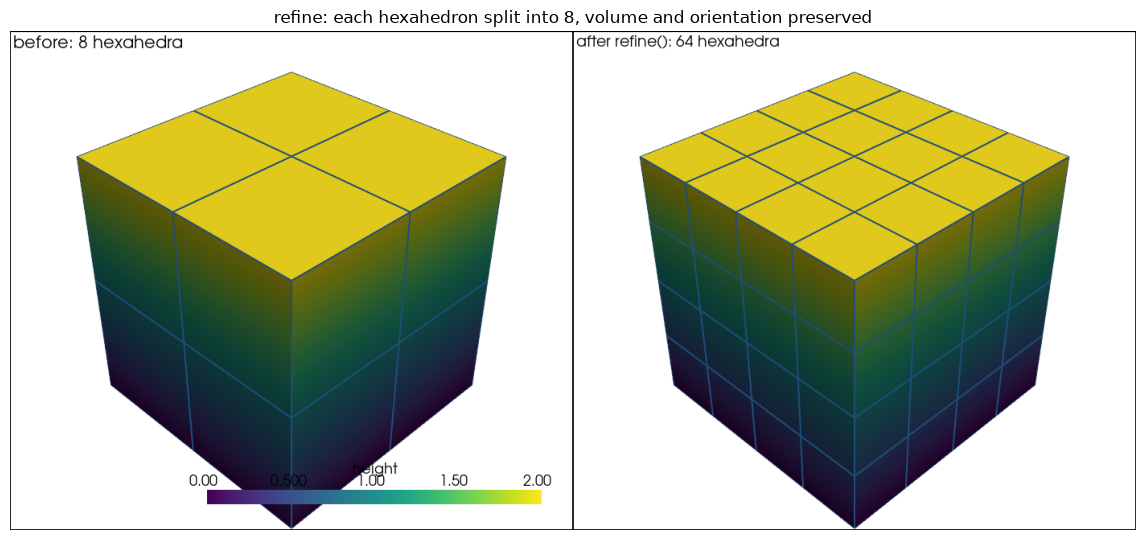

In [23]:
# A coarse 2x2x2 block of hexahedra, so the subdivision is easy to see.
n = 2
gx, gy, gz = np.meshgrid(*[np.arange(n + 1, dtype=float)] * 3, indexing='ij')
coarse_pts = np.column_stack([gx.ravel(), gy.ravel(), gz.ravel()])
pid = lambda i, j, k: (i * (n + 1) + j) * (n + 1) + k
coarse_conn = np.array([
    [pid(i, j, k), pid(i + 1, j, k), pid(i + 1, j + 1, k), pid(i, j + 1, k),
     pid(i, j, k + 1), pid(i + 1, j, k + 1), pid(i + 1, j + 1, k + 1), pid(i, j + 1, k + 1)]
    for i in range(n) for j in range(n) for k in range(n)
])
coarse = mp.Mesh(coarse_pts, [('hexahedron', coarse_conn)])

# A linear field, so we can check the interpolation is exact.
coarse.point_data['height'] = coarse.points[:, 2].copy()

fine = mp.refine(coarse)

cs, fs = mp.compute_stats(coarse), mp.compute_stats(fine)
print(f"coarse: {cs['num_cells']:3d} cells | {len(coarse.points):3d} points"
      f" | volume {cs['unsigned_volume']:.6f}")
print(f"fine  : {fs['num_cells']:3d} cells | {len(fine.points):3d} points"
      f" | volume {fs['unsigned_volume']:.6f}")
print('newly inverted cells:', fs['num_inverted'])

# A conforming 4x4x4 lattice has 5^3 = 125 nodes. Getting exactly that (rather
# than 8 x 27 = 216) is the proof that mid-edge and face-centre nodes are shared.
print(f"points: {len(fine.points)} (a conforming 5x5x5 lattice) "
      f"vs {len(coarse.cells[0].data) * 27} if every cell kept its own copy")

# The linear field is reproduced exactly on the new nodes.
err = np.abs(np.asarray(fine.point_data['height']) - fine.points[:, 2]).max()
print(f'max interpolation error on a linear field: {err:.2e}')

grid_coarse = to_pyvista(coarse)
grid_fine = to_pyvista(fine)

pl = pv.Plotter(off_screen=True, shape=(1, 2), window_size=(1400, 620))
pl.subplot(0, 0)
pl.add_text(f"before: {cs['num_cells']} hexahedra", font_size=10)
pl.add_mesh(grid_coarse, scalars='height', cmap='viridis', show_edges=True,
            edge_color='#1f4e79', line_width=2, scalar_bar_args={'title': 'height'})
pl.subplot(0, 1)
pl.add_text(f"after refine(): {fs['num_cells']} hexahedra", font_size=10)
pl.add_mesh(grid_fine, scalars='height', cmap='viridis', show_edges=True,
            edge_color='#1f4e79', line_width=2, scalar_bar_args={'title': 'height'})
pl.link_views()
pl.camera_position = 'iso'
img = pl.screenshot(return_img=True)
pl.close()

show(img, 'refine: each hexahedron split into 8, volume and orientation preserved',
     figsize=(13, 5.5), save='refine_hex')

## Selective (adaptive) refinement

The same operation refines a **subset** of the cells and closes the mesh back up
so it is still conforming. Give it a cell list, a region name, or — composing
directly with `attach_quality` — a threshold on a `cell_data` array.

The closure is what makes this usable: an affected neighbour is promoted to the
smallest split its cell type admits, not to a full one. For a hexahedron that
means refinement travels through one *dual sheet* rather than the whole block.
`record_levels=True` records each cell's depth in `refine:level`, which is what
we colour by below — a transitional cell keeps its parent's level, because a
closure is not a refinement.

(`closure="propagate"` is the honest alternative: always conforming and defined
for every cell type, but a fully split cell splits all of its edges, so the
cascade reaches the whole connected component — on a connected mesh it *is* the
uniform refinement. It is the baseline, not the adaptivity mode.)

     input:    64 cells
  redgreen:   125 cells
 propagate:   512 cells
   uniform:   512 cells
hanging nodes: 0
volume  in 64.000000  out 64.000000


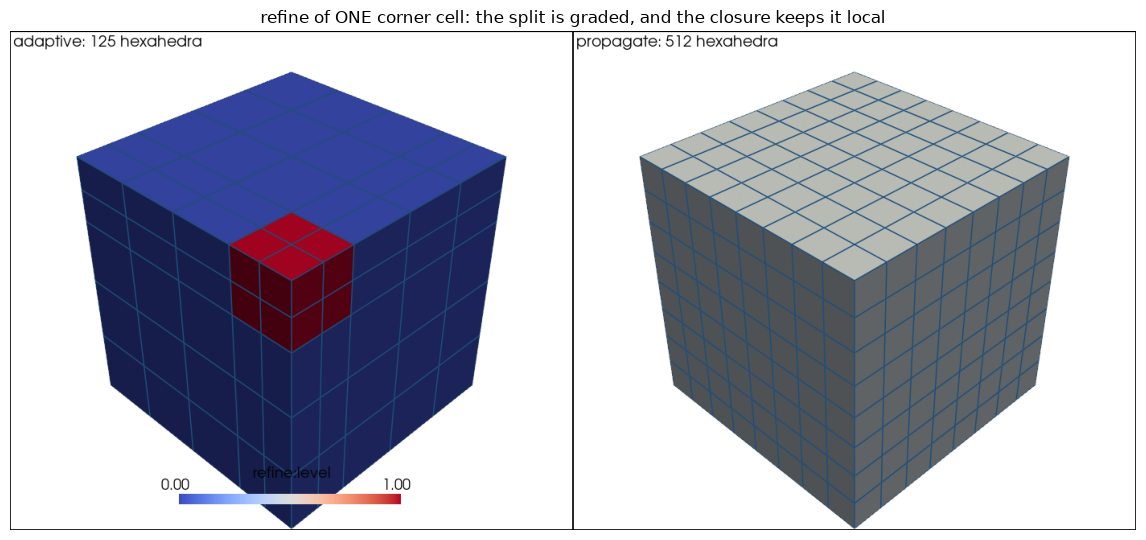

In [24]:
# A 4x4x4 block, with one corner cell selected. Anything the closure has to
# touch is the interesting part of the picture.
#
# Every name here is `adapt_`-prefixed on purpose: notebook cells share one
# global namespace, and the data-operations cells further down read `pts` (the
# bracket surface's coordinates) without reassigning it.
adapt_n = 4
adapt_gx, adapt_gy, adapt_gz = np.meshgrid(
    *[np.arange(adapt_n + 1, dtype=float)] * 3, indexing='ij')
adapt_pts = np.column_stack([adapt_gx.ravel(), adapt_gy.ravel(), adapt_gz.ravel()])
adapt_id = lambda i, j, k: (i * (adapt_n + 1) + j) * (adapt_n + 1) + k
adapt_conn = np.array([
    [adapt_id(i, j, k), adapt_id(i + 1, j, k), adapt_id(i + 1, j + 1, k), adapt_id(i, j + 1, k),
     adapt_id(i, j, k + 1), adapt_id(i + 1, j, k + 1), adapt_id(i + 1, j + 1, k + 1),
     adapt_id(i, j + 1, k + 1)]
    for i in range(adapt_n) for j in range(adapt_n) for k in range(adapt_n)
])
adapt_block = mp.Mesh(adapt_pts, [('hexahedron', adapt_conn)])

# The corner cell FACING the isometric camera, so the grading is actually
# visible: the loop above runs i, then j, then k.
adapt_sel = ((adapt_n - 1) * adapt_n + (adapt_n - 1)) * adapt_n + (adapt_n - 1)

adapt_graded = mp.refine(adapt_block, cells=[adapt_sel], record_levels=True)
adapt_flooded = mp.refine(adapt_block, cells=[adapt_sel], closure='propagate')
adapt_uniform = mp.refine(adapt_block)

for adapt_name, adapt_mesh in [('input', adapt_block), ('redgreen', adapt_graded),
                               ('propagate', adapt_flooded), ('uniform', adapt_uniform)]:
    print(f'{adapt_name:>10}: {mp.compute_stats(adapt_mesh)["num_cells"]:5d} cells')

# Conformity, asserted rather than eyeballed: no output node may sit exactly on
# another cell's edge midpoint. New nodes are order-independent corner means, so
# the comparison is exact.
from meshioplusplus._refine_templates import EDGES as ADAPT_EDGES

adapt_p = np.asarray(adapt_graded.points)
adapt_at = {tuple(q) for q in adapt_p}
adapt_hanging = sum(
    1
    for adapt_cb in adapt_graded.cells
    for adapt_a, adapt_b in ADAPT_EDGES[adapt_cb.type]
    for adapt_mid in (adapt_p[np.asarray(adapt_cb.data)[:, adapt_a]]
                      + adapt_p[np.asarray(adapt_cb.data)[:, adapt_b]]) * 0.5
    if tuple(adapt_mid) in adapt_at
)
print('hanging nodes:', adapt_hanging)

# Volume is untouched: refinement changes resolution, not the object.
print(f'volume  in {mp.compute_stats(adapt_block)["unsigned_volume"]:.6f}'
      f'  out {mp.compute_stats(adapt_graded)["unsigned_volume"]:.6f}')

pl = pv.Plotter(off_screen=True, shape=(1, 2), window_size=(1400, 620))
pl.subplot(0, 0)
pl.add_text(f'adaptive: {mp.compute_stats(adapt_graded)["num_cells"]} hexahedra', font_size=10)
# coolwarm rather than a sequential map: level 0 is most of the block, and a
# sequential map renders it near-black, hiding the very thing being shown.
pl.add_mesh(to_pyvista(adapt_graded), scalars='refine:level', cmap='coolwarm',
            clim=(0, 1), show_edges=True, edge_color='#1f4e79', line_width=1.5,
            scalar_bar_args={'title': 'refine:level', 'n_labels': 2,
                             'position_x': 0.3, 'width': 0.4, 'height': 0.06})
pl.subplot(0, 1)
pl.add_text(f'propagate: {mp.compute_stats(adapt_flooded)["num_cells"]} hexahedra', font_size=10)
pl.add_mesh(to_pyvista(adapt_flooded), color='#cfd8dc', show_edges=True,
            edge_color='#1f4e79', line_width=1.5)
pl.link_views()
pl.camera_position = 'iso'
img = pl.screenshot(return_img=True)
pl.close()

show(img, 'refine of ONE corner cell: the split is graded, and the closure keeps it local',
     figsize=(13, 5.5), save='refine_adaptive')


## Decimation (QEM edge collapse)

`decimate` is `refine`'s inverse: it *reduces* a surface mesh's face count by
greedy quadric-error-metric (Garland–Heckbert) edge collapse. Cheap collapses
are the ones that don't change the shape, so error-ordered greedy collapse
removes detail exactly where the surface is flat — while boundary vertices and
feature vertices (sharp creases) are pinned by default, and the link condition
plus a normal-flip guard reject anything that would change topology or fold
the surface. Volume meshes are refused by name: extract the skin first, then
decimate it.

skin  :  58394 triangles |  29151 points
coarse:  11678 triangles |   5793 points
removed 46716 faces, rejected 132977 collapses, max quadric error 5.65e-09
total area: 20.8405 -> 20.8413 (0.00% change)


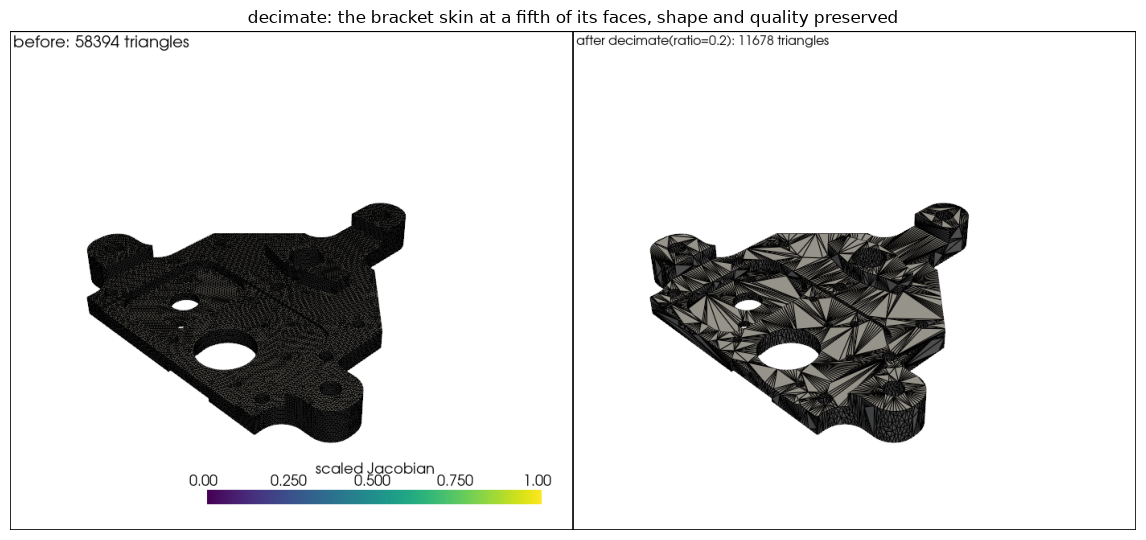

In [25]:
# Decimate the bracket's boundary skin to 10% of its triangles. Colouring both
# sides by element quality shows the collapse leaves well-shaped triangles even
# at a tenth of the resolution.
skin = mp.extract_surface(mesh)
coarse, rep = mp.decimate(skin, ratio=0.2, return_report=True)

faces_in = sum(len(cb.data) for cb in skin.cells)
faces_out = sum(len(cb.data) for cb in coarse.cells)
print(f"skin  : {faces_in:6d} triangles | {len(skin.points):6d} points")
print(f"coarse: {faces_out:6d} triangles | {len(coarse.points):6d} points")
print(f"removed {rep['faces_removed']} faces, rejected {rep['collapses_rejected']} "
      f"collapses, max quadric error {rep['max_error_applied']:.3g}")

# The shape survives: total area changes by well under a percent.
a_in = mp.compute_stats(skin)['total_area']
a_out = mp.compute_stats(coarse)['total_area']
print(f"total area: {a_in:.4f} -> {a_out:.4f} ({100 * abs(a_out - a_in) / a_in:.2f}% change)")

grid_full = to_pyvista(mp.attach_quality(skin))
grid_coarse = to_pyvista(mp.attach_quality(coarse))

pl = pv.Plotter(off_screen=True, shape=(1, 2), window_size=(1400, 620))
pl.subplot(0, 0)
pl.add_text(f"before: {faces_in} triangles", font_size=10)
pl.add_mesh(grid_full, scalars='quality:scaled_jacobian', cmap='viridis', clim=(0, 1),
            show_edges=True, line_width=1, scalar_bar_args={'title': 'scaled Jacobian'})
pl.subplot(0, 1)
pl.add_text(f"after decimate(ratio=0.2): {faces_out} triangles", font_size=10)
pl.add_mesh(grid_coarse, scalars='quality:scaled_jacobian', cmap='viridis', clim=(0, 1),
            show_edges=True, line_width=1, scalar_bar_args={'title': 'scaled Jacobian'})
pl.link_views()
pl.camera_position = 'iso'
img = pl.screenshot(return_img=True)
pl.close()

show(img, 'decimate: the bracket skin at a fifth of its faces, shape and quality preserved',
     figsize=(13, 5.5), save='decimate_before_after')

## Partitioning (N balanced parts)

`partition` decomposes a mesh into exactly N balanced pieces for domain
decomposition -- the *count-driven* complement to the criterion-driven `split`.
The default SFC method orders cells along a Hilbert space-filling curve of
their centroids and cuts it into contiguous ranges, so equal-weight part sizes
differ by at most one cell and the result is fully deterministic. With a
KaHIP-enabled build (or the MIT `kahip` wheel), `method="kahip"` swaps in
KaHIP's `kaffpa`, which actively minimizes the edge cut between parts.

Below: the bracket decomposed into 6 parts, coloured by the `partition:part`
label, next to an exploded view of the actual pieces `partition` returns.



part sizes: [49636, 49635, 49635, 49635, 49635, 49635] (max-min = 1 cells)


piece cell counts: [49636, 49635, 49635, 49635, 49635, 49635]


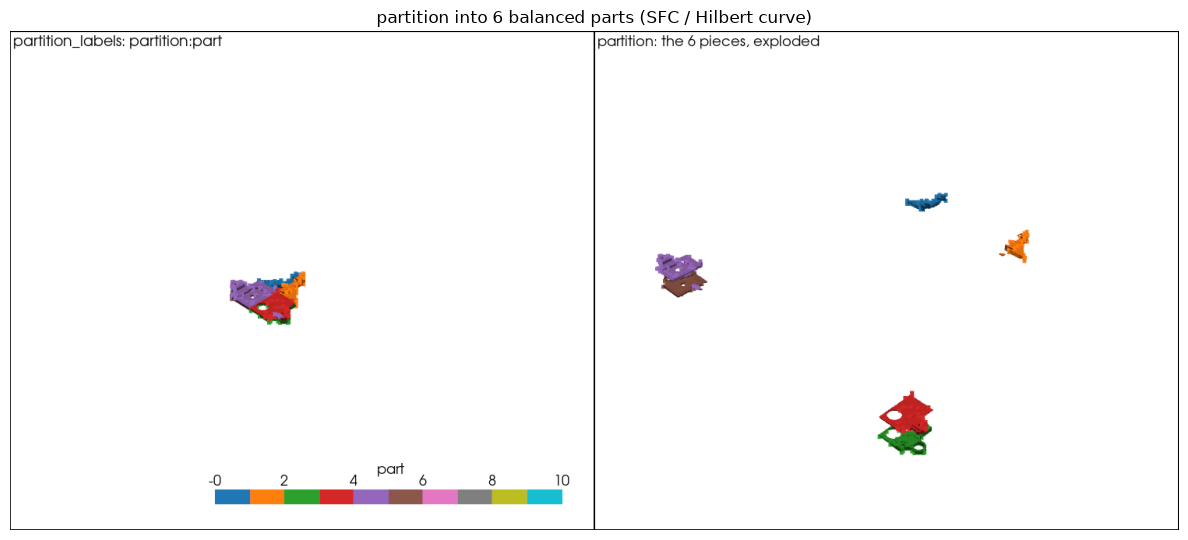

In [26]:
# Partition the bracket into 6 balanced parts. method='sfc' is pinned here so
# the committed outputs are deterministic; the default method='auto' upgrades
# to KaHIP's edge-cut optimizer whenever a KaHIP backend is available.
part_mesh = mp.read(EXAMPLE)
labels = mp.partition_labels(part_mesh, 6, method='sfc')
part_mesh.cell_data['partition:part'] = labels

flat = np.concatenate([np.asarray(b).reshape(-1) for b in labels]).astype(int)
sizes = np.bincount(flat, minlength=6)
print('part sizes:', sizes.tolist(), f'(max-min = {int(sizes.max() - sizes.min())} cells)')

# The pieces themselves: every piece keeps the input's block structure 1:1,
# so concatenating them reproduces the mesh -- each cell lands in exactly one.
pieces = mp.partition(part_mesh, 6, method='sfc')
print('piece cell counts:', [sum(len(cb.data) for cb in p.cells) for p in pieces])

try:
    pl = pv.Plotter(off_screen=True, shape=(1, 2), window_size=(1500, 640))
    pl.subplot(0, 0)
    pl.add_text('partition_labels: partition:part', font_size=10)
    pl.add_mesh(to_pyvista(part_mesh), scalars='partition:part', cmap='tab10',
                clim=(-0.5, 9.5), show_edges=False,
                scalar_bar_args={'title': 'part', 'n_labels': 6, 'fmt': '%.0f'})
    pl.subplot(0, 1)
    pl.add_text('partition: the 6 pieces, exploded', font_size=10)
    centre = np.asarray(part_mesh.points, dtype=float).mean(axis=0)
    cmap10 = plt.get_cmap('tab10')
    for part, piece in enumerate(pieces):
        grid = to_pyvista(piece)
        offset = np.asarray(piece.points, dtype=float).mean(axis=0) - centre
        norm = np.linalg.norm(offset)
        if norm > 0:
            grid = grid.translate((offset / norm) * 8.0, inplace=False)
        pl.add_mesh(grid, color=cmap10(part % 10), show_edges=False)
    pl.link_views()
    pl.camera_position = 'iso'
    img = pl.screenshot(return_img=True)
    pl.close()
    show(img, 'partition into 6 balanced parts (SFC / Hilbert curve)', figsize=(14, 5.5),
         save='partition_pieces')
except Exception as exc:  # pragma: no cover - head-less GL fallback
    print('PyVista render skipped:', exc)


## Smoothing (Laplacian / Taubin)

`smooth` improves *element shape* without changing anything else: it relaxes each free node
toward the centroid of its edge neighbours, so connectivity, cell counts and every data value
come through untouched and only the coordinates move. It is the natural repair pass for a mesh
that is topologically correct but geometrically ragged -- the output of a mesher, of
`convert_cells --mode simplexify`, or of a marching-cubes-style extractor.

Two operators. **Laplacian** moves each node a fraction `lambda` of the way to its centroid;
it smooths hard but shrinks the mesh, because it is a low-pass filter with no pass band.
**Taubin** (the default) follows every `+lambda` pass with a slightly larger `-mu` pass, an
explicit un-shrinking step that gives the pair a pass band -- so features survive and the
volume does not collapse.

Boundary nodes are pinned by default, as are geometric corners and creases (`preserve_features`),
and an inversion guard refuses any move that would turn a valid cell inside out. Below: a hex
block whose interior has been jittered until several cells invert, coloured by scaled Jacobian
before and after (1.0 is a perfect cube, negative is inverted).

points 125 -> 125   cells 64 -> 64   (unchanged: smooth only moves nodes)
min scaled Jacobian : -0.7666 ->  0.9071
mean skewness       :  0.6144 ->  0.1496
inverted cells      :       1 ->       0
volume              :  64.148 ->  64.000   (the exact block is 64)
report              : {'num_nodes_moved': 27, 'max_displacement': 1.0120929556164175, 'num_skipped_inversion': 0}


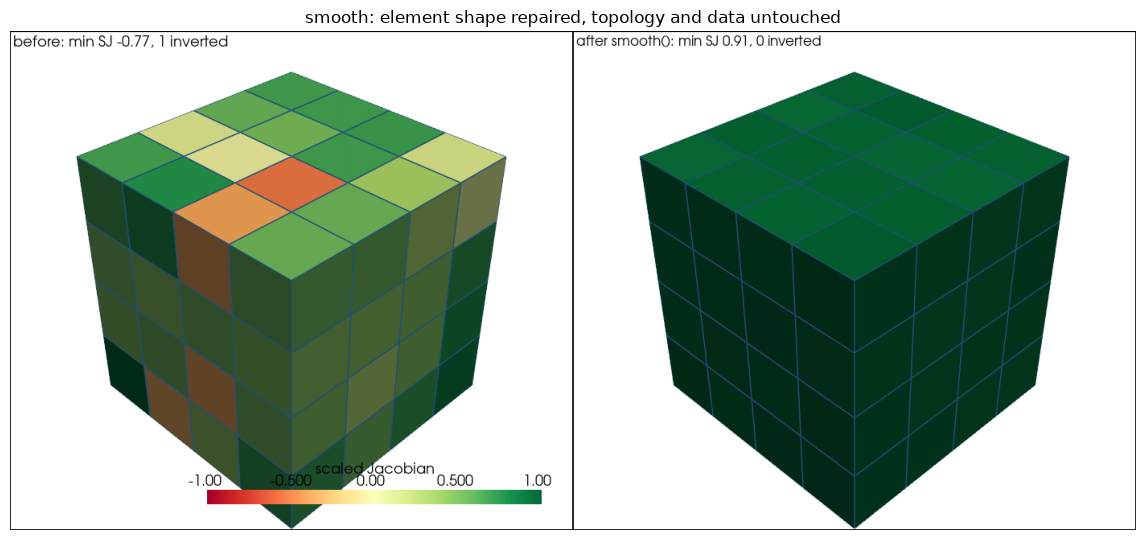

In [27]:
# A 4x4x4 hex block whose interior nodes are jittered hard enough to tangle
# several cells. The seed is pinned so the committed outputs stay deterministic.
n = 4
grid = np.meshgrid(*[np.arange(n + 1, dtype=float)] * 3, indexing='ij')
block_pts = np.column_stack([a.ravel() for a in grid])


def hid(i, j, k):
    return (i * (n + 1) + j) * (n + 1) + k


block_conn = np.array([
    [hid(i, j, k), hid(i + 1, j, k), hid(i + 1, j + 1, k), hid(i, j + 1, k),
     hid(i, j, k + 1), hid(i + 1, j, k + 1), hid(i + 1, j + 1, k + 1), hid(i, j + 1, k + 1)]
    for i in range(n) for j in range(n) for k in range(n)
])

rough = mp.Mesh(block_pts.copy(), [('hexahedron', block_conn)])
interior = [i for i in range(len(block_pts)) if all(0 < c < n for c in block_pts[i])]
rng = np.random.default_rng(3)
rough.points[interior] += rng.normal(0, 0.35, (len(interior), 3))

relaxed, report = mp.smooth(rough, iterations=20, return_report=True)

q0 = mp.compute_quality(rough)['metrics']
q1 = mp.compute_quality(relaxed)['metrics']
s0, s1 = mp.compute_stats(rough), mp.compute_stats(relaxed)

print(f"points {len(rough.points)} -> {len(relaxed.points)}   "
      f"cells {s0['num_cells']} -> {s1['num_cells']}   (unchanged: smooth only moves nodes)")
print(f"min scaled Jacobian : {q0['quality:scaled_jacobian']['min']:7.4f}"
      f" -> {q1['quality:scaled_jacobian']['min']:7.4f}")
print(f"mean skewness       : {q0['quality:skewness']['mean']:7.4f}"
      f" -> {q1['quality:skewness']['mean']:7.4f}")
print(f"inverted cells      : {s0['num_inverted']:7d} -> {s1['num_inverted']:7d}")
print(f"volume              : {s0['unsigned_volume']:7.3f} -> {s1['unsigned_volume']:7.3f}"
      f"   (the exact block is {n ** 3})")
print(f"report              : {report}")

# Colour both by their own scaled Jacobian, on a shared scale so the comparison
# is honest rather than flattered by per-panel autoscaling.
before = to_pyvista(mp.attach_quality(rough))
after = to_pyvista(mp.attach_quality(relaxed))
clim = (-1.0, 1.0)

try:
    pl = pv.Plotter(off_screen=True, shape=(1, 2), window_size=(1400, 620))
    pl.subplot(0, 0)
    pl.add_text(f"before: min SJ {q0['quality:scaled_jacobian']['min']:.2f},"
                f" {s0['num_inverted']} inverted", font_size=10)
    pl.add_mesh(before, scalars='quality:scaled_jacobian', cmap='RdYlGn', clim=clim,
                show_edges=True, edge_color='#1f4e79', line_width=1.5,
                scalar_bar_args={'title': 'scaled Jacobian'})
    pl.subplot(0, 1)
    pl.add_text(f"after smooth(): min SJ {q1['quality:scaled_jacobian']['min']:.2f},"
                f" {s1['num_inverted']} inverted", font_size=10)
    pl.add_mesh(after, scalars='quality:scaled_jacobian', cmap='RdYlGn', clim=clim,
                show_edges=True, edge_color='#1f4e79', line_width=1.5,
                scalar_bar_args={'title': 'scaled Jacobian'})
    pl.link_views()
    pl.camera_position = 'iso'
    img = pl.screenshot(return_img=True)
    pl.close()
    show(img, 'smooth: element shape repaired, topology and data untouched',
         figsize=(13, 5.5), save='smooth_quality')
except Exception as exc:  # pragma: no cover - head-less GL fallback
    print('PyVista render skipped:', exc)

mean bounding-box span: input 12.646 | laplacian 7.426 (41% smaller) | taubin 11.847 (6% smaller)


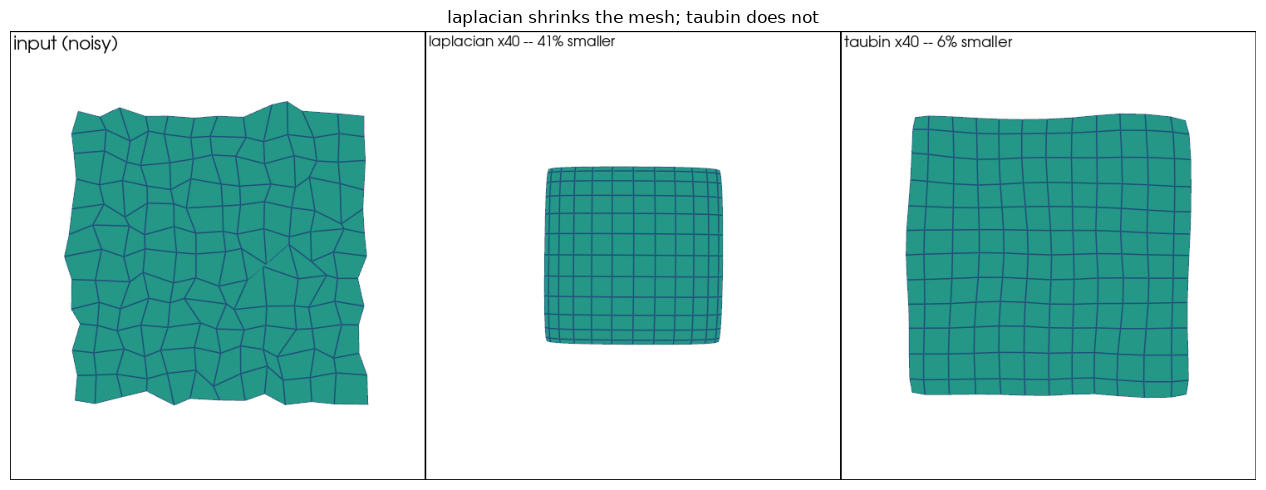

In [28]:
# Why Taubin is the default: run both operators to convergence on the same
# noisy grid with the boundary deliberately left free, and watch the footprint.
side = 13
xs, ys = np.meshgrid(np.arange(side, dtype=float), np.arange(side, dtype=float), indexing='ij')
noisy = mp.Mesh(
    np.column_stack([xs.ravel(), ys.ravel()]),
    [('quad', np.array([[i * side + j, (i + 1) * side + j,
                         (i + 1) * side + j + 1, i * side + j + 1]
                        for i in range(side - 1) for j in range(side - 1)]))],
)
noisy.points += np.random.default_rng(0).normal(0, 0.18, noisy.points.shape)

free = dict(fix_boundary=False, preserve_features=False, guard_inversion=False)
lap = mp.smooth(noisy, method='laplacian', iterations=40, **free)
tau = mp.smooth(noisy, method='taubin', iterations=40, **free)

span = lambda m: np.ptp(np.asarray(m.points), axis=0).mean()
print(f"mean bounding-box span: input {span(noisy):.3f}"
      f" | laplacian {span(lap):.3f} ({100 * (1 - span(lap) / span(noisy)):.0f}% smaller)"
      f" | taubin {span(tau):.3f} ({100 * (1 - span(tau) / span(noisy)):.0f}% smaller)")

try:
    pl = pv.Plotter(off_screen=True, shape=(1, 3), window_size=(1500, 540))
    for col, (m, label) in enumerate([
        (noisy, 'input (noisy)'),
        (lap, f'laplacian x40 -- {100 * (1 - span(lap) / span(noisy)):.0f}% smaller'),
        (tau, f'taubin x40 -- {100 * (1 - span(tau) / span(noisy)):.0f}% smaller'),
    ]):
        pl.subplot(0, col)
        pl.add_text(label, font_size=10)
        pl.add_mesh(to_pyvista(m), color='#2ec4b6', show_edges=True,
                    edge_color='#1f4e79', line_width=1.5)
    pl.link_views()
    pl.camera_position = 'xy'
    img = pl.screenshot(return_img=True)
    pl.close()
    show(img, 'laplacian shrinks the mesh; taubin does not', figsize=(14, 5),
         save='smooth_shrinkage')
except Exception as exc:  # pragma: no cover - head-less GL fallback
    print('PyVista render skipped:', exc)

## Field interpolation (cross-mesh transfer)

`interpolate(source, target)` is the first **two-mesh** operation that moves
*data*: it returns a copy of the target with the source's arrays sampled onto
it (source `point_data` at the target's points, source `cell_data` by nearest
source-cell centroid). `method="nearest"` copies the nearest source point's
value bit-for-bit; `method="barycentric"` simplexifies the source and
interpolates linearly — exact on a linear field, with `default_value` /
`extrapolate` deciding what happens outside the source domain. Output is
byte-identical across backends, thread counts, and the C++/numpy boundary.

transferred 'f' from 343 onto 15625 points
max |error| on a linear field: 3.552713678800501e-15


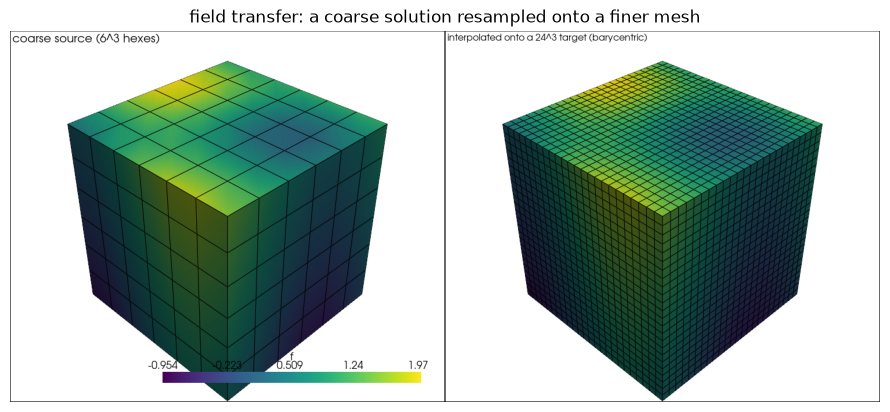

In [29]:
# A coarse 'solution' on a 6^3 hex grid, resampled onto a 4x finer target.
def hex_grid(n):
    xs = np.linspace(0.0, 1.0, n + 1)
    gpts = np.array([[x, y, z] for z in xs for y in xs for x in xs])
    m = n + 1

    def pid(i, j, k):
        return (k * m + j) * m + i

    gcells = [
        [pid(i, j, k), pid(i + 1, j, k), pid(i + 1, j + 1, k), pid(i, j + 1, k),
         pid(i, j, k + 1), pid(i + 1, j, k + 1), pid(i + 1, j + 1, k + 1),
         pid(i, j + 1, k + 1)]
        for k in range(n) for j in range(n) for i in range(n)
    ]
    return mp.Mesh(gpts, [('hexahedron', np.array(gcells))])


coarse = hex_grid(6)
cp = coarse.points
coarse.point_data['f'] = np.sin(4.0 * cp[:, 0]) * np.cos(4.0 * cp[:, 1]) + cp[:, 2]

fine = hex_grid(24)
mapped = mp.interpolate(coarse, fine, method='barycentric')
print(f"transferred 'f' from {len(coarse.points)} onto {len(mapped.points)} points")

# The transfer is linear-exact: a linear field survives to round-off.
coarse.point_data['lin'] = 2 * cp[:, 0] + 3 * cp[:, 1] + 5 * cp[:, 2]
lin = mp.interpolate(coarse, fine, method='barycentric', arrays=['lin'])
fp = fine.points
print('max |error| on a linear field:',
      np.abs(lin.point_data['lin'] - (2 * fp[:, 0] + 3 * fp[:, 1] + 5 * fp[:, 2])).max())

try:
    pl = pv.Plotter(off_screen=True, shape=(1, 2), window_size=(1500, 640))
    pl.subplot(0, 0)
    pl.add_text('coarse source (6^3 hexes)', font_size=10)
    pl.add_mesh(to_pyvista(coarse), scalars='f', cmap='viridis', show_edges=True)
    pl.subplot(0, 1)
    pl.add_text('interpolated onto a 24^3 target (barycentric)', font_size=10)
    pl.add_mesh(to_pyvista(mapped), scalars='f', cmap='viridis', show_edges=True)
    pl.link_views()
    pl.camera_position = 'iso'
    img = pl.screenshot(return_img=True)
    pl.close()
    show(img, 'field transfer: a coarse solution resampled onto a finer mesh',
         save='interpolate_transfer')
except Exception as exc:  # pragma: no cover - head-less GL fallback
    print('PyVista render skipped:', exc)

## Cross-section (slice)

`slice` computes the planar **cross-section** of a mesh &mdash; the actual intersection with a plane, one topological dimension below the cut cells (a volume mesh &rarr; a `triangle`/`quad` surface). Unlike `crop`, which keeps whole cells on one side, `slice` intersects and lowers the dimension. It uses marching tetrahedra on a simplexified copy, dedupes cut points on shared edges (watertight), and interpolates `point_data` at the cut. Below, the bracket is cut by a horizontal mid-plane: the translucent volume shows where the section sits, and the section is coloured by an interpolated height field.


section: 19280 points, 28785 faces (triangle, quad)


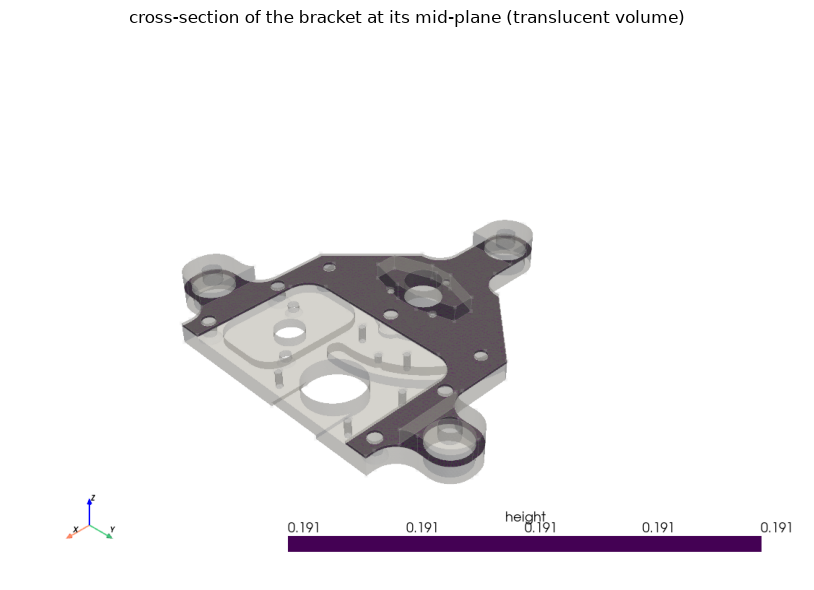

In [30]:
# Cut the bracket by a horizontal mid-plane. slice() intersects the volume,
# returning a triangle/quad surface one dimension lower (crop would instead
# keep whole cells on one side of the plane).
vol = mp.read(EXAMPLE)
vp = np.asarray(vol.points, dtype=float)
lo, hi = vp.min(axis=0), vp.max(axis=0)
mid = 0.5 * (lo + hi)
# a smooth field carried through the cut, so point_data interpolation is visible
vol.point_data['height'] = vp[:, 2].copy()

section = mp.slice(vol, origin=mid, normal=(0, 0, 1), record_parent_ids=True)
nfaces = sum(len(cb.data) for cb in section.cells)
print(f"section: {len(section.points)} points, {nfaces} faces "
      f"({', '.join(cb.type for cb in section.cells)})")

try:
    pl = pv.Plotter(off_screen=True, window_size=(1100, 760))
    pl.add_mesh(to_pyvista(vol), color='#c9c9c9', opacity=0.18, show_edges=False)
    pl.add_mesh(to_pyvista(section), scalars='height', cmap='viridis',
                show_edges=True, edge_color='#333333', line_width=0.5)
    pl.camera_position = 'iso'
    pl.add_axes()
    img = pl.screenshot(return_img=True)
    pl.close()
    show(img, 'cross-section of the bracket at its mid-plane (translucent volume)',
         save='slice_section')
except Exception as exc:  # pragma: no cover - head-less GL fallback
    print('PyVista render skipped:', exc)


## Isosurfaces / contours

`isosurface` computes the **level set** of a scalar field &mdash; the locus where a `point_data` array equals a given isovalue, as a mesh one topological dimension below the cut cells. It is the *data-driven* sibling of `slice`: slice cuts where the distance to a plane is zero, isosurface where `f(x) - isovalue` is. They share one marching-tetrahedra cutter, so contours are watertight in the same way, and the contoured field reads back as **exactly** the isovalue on the cut points.

Several isovalues land in one mesh, cut in ascending order and tagged per cell with a Float64 `iso:value` and an Int64 `iso:index` (the ordinal &mdash; the integer tag `split(by='tag')` needs). The field must be `point_data`: `cell_data` is piecewise constant and has no level set, so naming one raises and points at `cell_data_to_point_data`.



contours: 11249 points, 15292 faces (triangle, quad)
levels (ascending): [0.8732, 1.2521, 1.6611]
distinct values of r on the contours: [np.float64(0.873205), np.float64(1.25206), np.float64(1.661078)]
split by iso:index -> {'0': 6087, '1': 4550, '2': 4655} faces


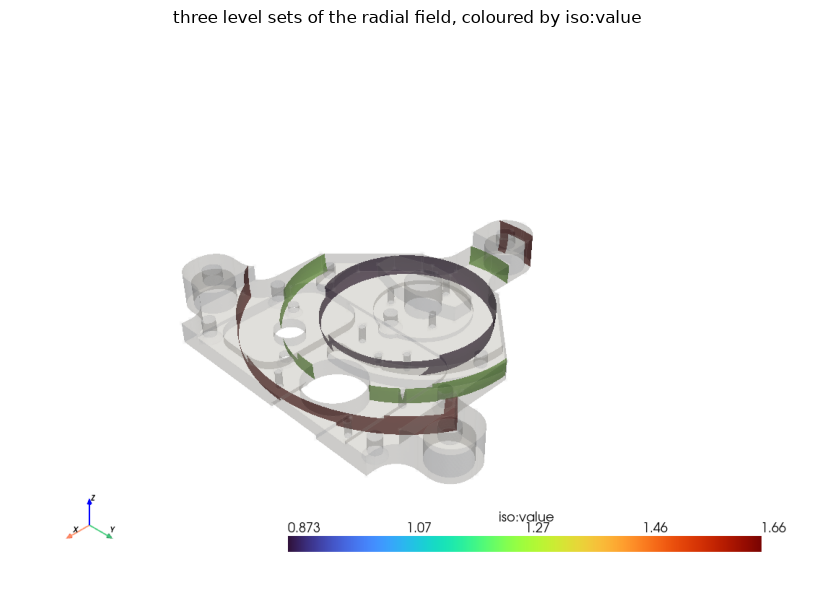

In [31]:
# Three nested level sets of a smooth field on the bracket. isosurface()
# returns one mesh holding every contour, tagged per cell with iso:value
# (the level) and iso:index (its ordinal -- the integer split() needs).
vol = mp.read(EXAMPLE)
vp = np.asarray(vol.points, dtype=float)
lo, hi = vp.min(axis=0), vp.max(axis=0)
centre = 0.5 * (lo + hi)
radius = np.linalg.norm(vp - centre, axis=1)
vol.point_data['r'] = radius

levels = [float(np.quantile(radius, q)) for q in (0.35, 0.55, 0.75)]
shells = mp.isosurface(vol, 'r', levels, record_parent_ids=True)
nfaces = sum(len(cb.data) for cb in shells.cells)
tags = np.concatenate([np.asarray(b) for b in shells.cell_data['iso:value']])
print(f"contours: {len(shells.points)} points, {nfaces} faces "
      f"({', '.join(cb.type for cb in shells.cells)})")
print('levels (ascending):', [round(v, 4) for v in sorted(set(tags.tolist()))])
# The contoured field is written exactly, not merely interpolated close.
per_level = {round(v, 6) for v in np.asarray(shells.point_data['r'])}
print('distinct values of r on the contours:', sorted(per_level))

# One mesh per contour, via the integer ordinal tag.
pieces = mp.split(shells, by='region', tag='iso:index')
print('split by iso:index ->', {k: sum(len(cb.data) for cb in m.cells)
                                for k, m in pieces.items()}, 'faces')

try:
    pl = pv.Plotter(off_screen=True, window_size=(1100, 760))
    pl.add_mesh(to_pyvista(vol), color='#c9c9c9', opacity=0.12, show_edges=False)
    pl.add_mesh(to_pyvista(shells), scalars='iso:value', cmap='turbo',
                show_edges=False, opacity=0.85)
    pl.camera_position = 'iso'
    pl.add_axes()
    img = pl.screenshot(return_img=True)
    pl.close()
    show(img, 'three level sets of the radial field, coloured by iso:value',
         save='isosurface_shells')
except Exception as exc:  # pragma: no cover - head-less GL fallback
    print('PyVista render skipped:', exc)


## Field derivatives &mdash; gradient, divergence, curl

`gradient` differentiates a `point_data` field: its **gradient**, **divergence** or **curl**. Everything above transforms, transfers, summarizes or contours a field; this is what lets us *differentiate* one &mdash; which is the missing input for the two things below it: contouring a **derived** quantity, and driving the selective `refine` from a gradient-based error indicator.

Two methods. **Green-Gauss** (the default) applies the divergence theorem over the cell, fanning each face into triangles about its corner average; that is *exact* for a linear field on any cell, planar faces or not. **Least-squares** fits over the cells sharing a node, and falls back to Green-Gauss &mdash; counted, never silently wrong &mdash; where the neighbourhood is degenerate.

The result is `Float64`, named `<input>:gradient` / `:divergence` / `:curl`, at the cell (default) or point location. A `cell_data` input raises by name: a piecewise-constant field has no derivative. Cells that cannot be differentiated yield NaN and are **counted**, never approximated.


grad shape (52282, 3)  (a scalar field -> 3 components per point)
cells skipped (NaN): 62797 of 297811, fell back to Green-Gauss: 0
|grad r|: median 0.9993 (exact answer: 1)


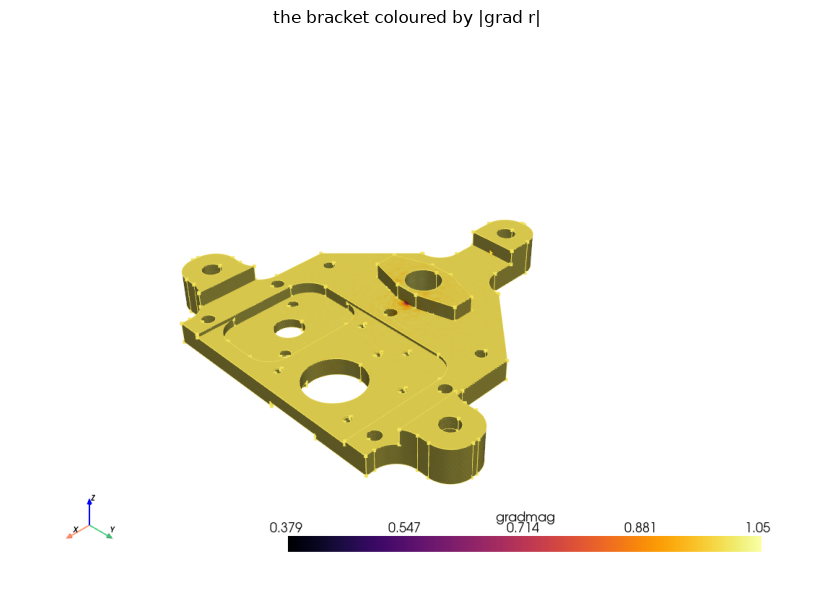

In [32]:
# The gradient of a smooth field on the bracket. The geometry is untouched --
# this operation only attaches an array -- so we can colour the mesh itself by
# |grad r| to see where the field changes fastest.
vol = mp.read(EXAMPLE)
vp = np.asarray(vol.points, dtype=float)
lo, hi = vp.min(axis=0), vp.max(axis=0)
centre = 0.5 * (lo + hi)
vol.point_data['r'] = np.linalg.norm(vp - centre, axis=1)

g, report = mp.gradient(vol, 'r', location='point', return_report=True)
grad = np.asarray(g.point_data['r:gradient'])
g.point_data['gradmag'] = np.sqrt((grad ** 2).sum(axis=1))
print(f"grad shape {grad.shape}  (a scalar field -> 3 components per point)")

# The bracket carries line/vertex/triangle marker blocks alongside its tetra
# block. They are below the mesh's own topological dimension, so they are
# reported as skipped and their rows are NaN -- never quietly approximated.
ncells = sum(len(cb.data) for cb in vol.cells)
print(f"cells skipped (NaN): {report['num_skipped']} of {ncells}, "
      f"fell back to Green-Gauss: {report['num_fallback']}")

# For r = |x - centre| the exact gradient is the unit radial vector, so its
# magnitude is 1 everywhere away from the centre -- a check with a known answer.
mag = np.asarray(g.point_data['gradmag'])
print(f"|grad r|: median {np.median(mag):.4f} (exact answer: 1)")

try:
    pl = pv.Plotter(off_screen=True, window_size=(1100, 760))
    pl.add_mesh(to_pyvista(g), scalars='gradmag', cmap='inferno',
                show_edges=False)
    pl.camera_position = 'iso'
    pl.add_axes()
    img = pl.screenshot(return_img=True)
    pl.close()
    show(img, 'the bracket coloured by |grad r|', save='gradient_magnitude')
except Exception as exc:  # pragma: no cover - head-less GL fallback
    print('PyVista render skipped:', exc)


|grad r| contour: 92612 points, 128999 faces
refine where err > 1.023: 235014 -> 392560 cells (refining everything would give 1880112)


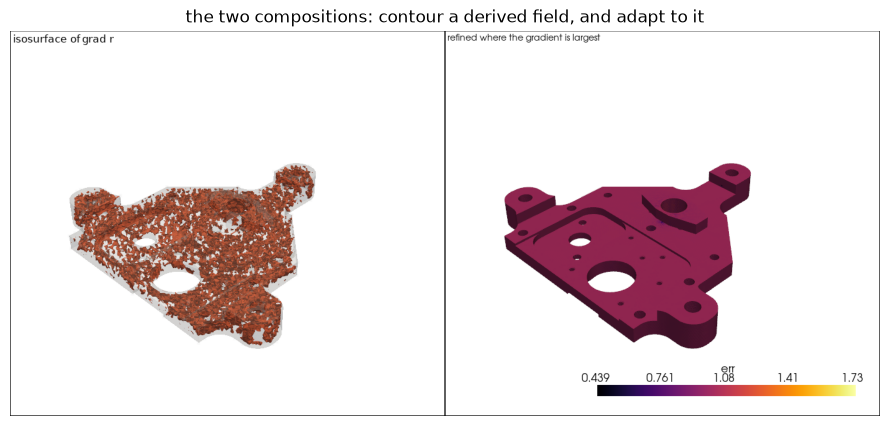

In [33]:
# The two reasons this operation exists.
#
# (1) Contour a DERIVED quantity: isosurface needs a point_data scalar, and a
#     gradient magnitude is exactly that.
shells = mp.isosurface(g, 'gradmag', [float(np.quantile(mag, 0.75))])
print(f"|grad r| contour: {len(shells.points)} points, "
      f"{sum(len(cb.data) for cb in shells.cells)} faces")

# (2) Drive adaptive refinement: refine --where takes any scalar cell_data, and
#     a gradient magnitude is the classic error indicator. refine subdivides
#     cells into same-type children, so take the tetra block on its own.
tets = mp.split(vol, by='type')['tetra']
gc = mp.gradient(tets, 'r')                      # cell-located this time
gmag = [np.sqrt((np.asarray(a) ** 2).sum(axis=1)) for a in gc.cell_data['r:gradient']]
gc.cell_data['err'] = gmag
flat = np.concatenate(gmag)
threshold = float(np.quantile(flat, 0.98))
before = sum(len(cb.data) for cb in gc.cells)
adapted = mp.refine(gc, where=f'err > {threshold}')
after = sum(len(cb.data) for cb in adapted.cells)
print(f"refine where err > {threshold:.3f}: {before} -> {after} cells "
      f"(refining everything would give {before * 8})")

try:
    pl = pv.Plotter(off_screen=True, shape=(1, 2), window_size=(1400, 620))
    pl.subplot(0, 0)
    pl.add_mesh(to_pyvista(vol), color='#c9c9c9', opacity=0.10)
    pl.add_mesh(to_pyvista(shells), color='#e4572e', show_edges=False)
    pl.add_text('isosurface of |grad r|', font_size=9)
    pl.camera_position = 'iso'
    pl.subplot(0, 1)
    pl.add_mesh(to_pyvista(adapted), scalars='err', cmap='inferno',
                show_edges=False)
    pl.add_text('refined where the gradient is largest', font_size=9)
    pl.camera_position = 'iso'
    img = pl.screenshot(return_img=True)
    pl.close()
    show(img, 'the two compositions: contour a derived field, and adapt to it',
         save='gradient_compositions')
except Exception as exc:  # pragma: no cover - head-less GL fallback
    print('PyVista render skipped:', exc)


## The settings pipeline

Every operation above can also be chained **declaratively**: one
`settings.json` describes read &rarr; operations &rarr; write, and
`mp.run_pipeline` (or `meshioplusplus pipeline settings.json` from either CLI,
and the same engine from C/Fortran/Julia/R/WASM) executes it. Ops and keys are
PascalCase, enum values keep their usual lowercase spellings, and parsing is
strict &mdash; an unknown op or key is an error naming it. See
[the settings pipeline](https://loumalouomega.github.io/meshioplusplus/pipeline).

step 1: Transform
step 2: ExtractSurface
step 3: Quality
step 4: Clean {'PointsWelded': 0, 'PointsRemovedOrphan': 0, 'CellsDroppedDegenerate': 0, 'CellsDroppedDuplicate': 0}


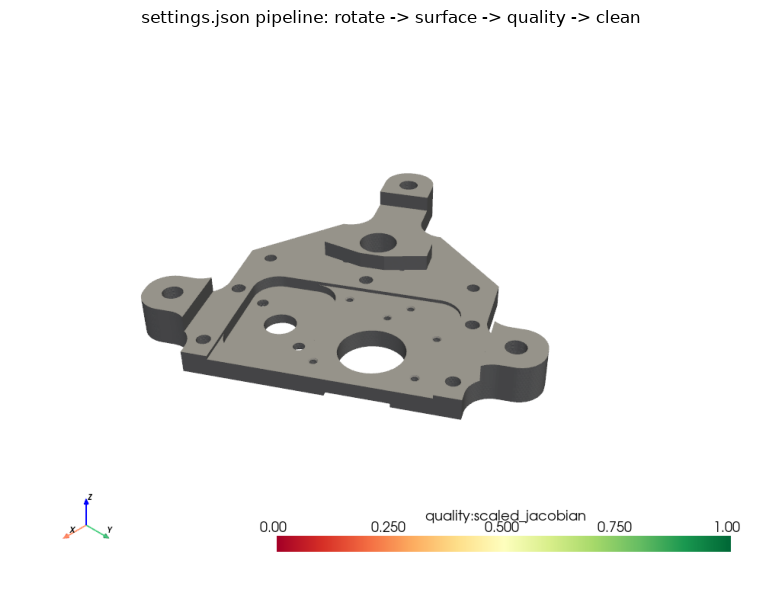

In [34]:
# One document instead of four verb invocations with intermediate files:
# rotate the bracket, extract its boundary, attach quality metrics, clean up.
import json

pipe_dir = tempfile.mkdtemp()
pipe_out = os.path.join(pipe_dir, 'pipeline_out.vtu')
settings = {
    'Version': 1,
    'Input': {'Path': EXAMPLE},
    'Operations': [
        {'Op': 'Transform', 'RotateAxis': [0, 0, 1], 'RotateDegrees': 30},
        {'Op': 'ExtractSurface'},
        {'Op': 'Quality'},
        {'Op': 'Clean'},
    ],
    'Output': {'Path': pipe_out},
}
settings_path = os.path.join(pipe_dir, 'settings.json')
with open(settings_path, 'w') as f:
    json.dump(settings, f, indent=2)

report = mp.run_pipeline(settings_path)   # a dict, JSON text or a path all work
for i, step in enumerate(report['steps'], start=1):
    counters = {k: v for k, v in step.items() if k != 'op'}
    print(f"step {i}: {step['op']}" + (f' {counters}' if counters else ''))

piped = mp.read(pipe_out)
render(piped, 'settings.json pipeline: rotate -> surface -> quality -> clean',
       scalars='quality:scaled_jacobian', cmap='RdYlGn', clim=(0.0, 1.0))

Every operation shown here is also exposed through the C API, the Fortran
module, and the WebAssembly build, and as a `meshioplusplus` CLI verb.

## Transient sequences (multi-file datasets)

Most formats cannot express time at all, so transient solver output usually
arrives as a *set* of files &mdash; `out_0000.vtu … out_0500.vtu`. meshio++
treats such a set as **one ordered dataset**: `mp.read_sequence` yields
`(time, mesh)` lazily, `mp.write_sequence` fans a set **in** to one multi-step
XDMF or **out** to one file per step, and a `settings.json` whose `Input` is a
pattern runs the whole operation chain **per step**.

Two things are contracts rather than conveniences. Ordering is
**natural-numeric**, so `out_10.vtu` follows `out_9.vtu` (a plain sort gets that
backwards). And the drivers **stream**: exactly one mesh is alive at a time, so
a 500-step dataset costs no more memory than a one-step one. See
[sequences](https://loumalouomega.github.io/meshioplusplus/sequences).

In [35]:
# A synthetic time series: the bracket's surface, oscillating along z.
seq_dir = tempfile.mkdtemp()
base = mp.extract_surface(mesh)
n_steps = 12
for k in range(n_steps):
    step = base.copy()
    step.points = base.points.copy()
    step.points[:, 2] += 3.0 * np.sin(2 * np.pi * k / n_steps)
    step.point_data['height'] = step.points[:, 2].copy()
    # Deliberately UNPADDED names, so the ordering rule has something to prove.
    mp.write(os.path.join(seq_dir, f'out_{k}.vtu'), step)

pattern = os.path.join(seq_dir, 'out_*.vtu')
plan = mp.sequence_entries(pattern)
print(f'{len(plan)} steps, in natural-numeric order:')
print('  ', ', '.join(os.path.basename(e['path']) for e in plan))
print('   lexicographic order would put out_10 third:',
      ', '.join(sorted(os.path.basename(e['path']) for e in plan)[:4]), '...')
print(f"   times {[e['time'] for e in plan]} (source: {plan[0]['time_source']})")

12 steps, in natural-numeric order:
   out_0.vtu, out_1.vtu, out_2.vtu, out_3.vtu, out_4.vtu, out_5.vtu, out_6.vtu, out_7.vtu, out_8.vtu, out_9.vtu, out_10.vtu, out_11.vtu
   lexicographic order would put out_10 third: out_0.vtu, out_1.vtu, out_10.vtu, out_11.vtu ...
   times [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0] (source: filename)


In [36]:
# Fan-in: 12 single-step files -> one multi-step XDMF, streaming.
series = os.path.join(seq_dir, 'series.xdmf')
mp.write_sequence(series, mp.read_sequence(pattern))
print('fan-in ->', os.path.basename(series),
      f'({len(mp.sequence_entries(series))} steps; times now come from the file itself)')

# Fan-out: back to one file per step, with a {step} token in the path.
fanned = mp.write_sequence(os.path.join(seq_dir, 'step_{step}.vtu'),
                           mp.read_sequence(series))
print('fan-out ->', ', '.join(os.path.basename(p) for p in fanned[:3]), '...')

# A transient post-processing run: the chain is applied to EVERY step.
seq_report = mp.run_pipeline({
    'Version': 1,
    'Input': {'Pattern': pattern},
    'Operations': [{'Op': 'Quality'}],
    'Output': {'Path': os.path.join(seq_dir, 'post_{step}.vtu')},
})
print(f"per-step pipeline: {len(seq_report['steps'])} step-operations over {len(plan)} files")

fan-in -> series.xdmf (12 steps; times now come from the file itself)


fan-out -> step_0000.vtu, step_0001.vtu, step_0002.vtu ...


per-step pipeline: 12 step-operations over 12 files


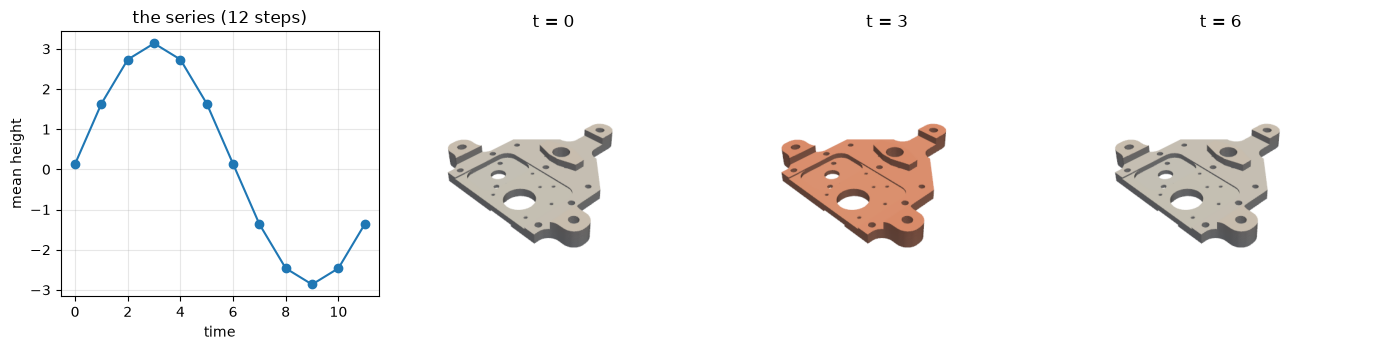

In [37]:
# The whole series in one figure: every step's mean height, plus three frames
# rendered from the fanned-out files. Reading is lazy throughout -- only one
# mesh is ever alive.
times, means = [], []
for t, m in mp.read_sequence(series):
    times.append(t)
    means.append(float(m.point_data['height'].mean()))


def frame_image(mesh, clim):
    """An off-screen RGB render, for embedding several side by side."""
    grid = to_pyvista(mesh)
    pl = pv.Plotter(off_screen=True, window_size=(520, 420))
    pl.add_mesh(grid, scalars='height', cmap='coolwarm', clim=clim,
                show_edges=False, show_scalar_bar=False)
    pl.camera_position = 'iso'
    img = pl.screenshot(return_img=True)
    pl.close()
    return img


try:
    lo, hi = min(means) - 4.0, max(means) + 4.0
    fig = plt.figure(figsize=(14, 3.6))
    ax = fig.add_subplot(1, 4, 1)
    ax.plot(times, means, 'o-', color='#1f77b4')
    ax.set_xlabel('time')
    ax.set_ylabel('mean height')
    ax.set_title('the series (12 steps)')
    ax.grid(alpha=0.3)
    for col, k in enumerate([0, 3, 6]):
        frame = mp.read(os.path.join(seq_dir, f'step_{k:04d}.vtu'))
        ax = fig.add_subplot(1, 4, col + 2)
        ax.imshow(frame_image(frame, (lo, hi)))
        ax.set_title(f't = {times[k]:g}')
        ax.axis('off')
    fig.tight_layout()
    save_fig('sequence_frames')
    plt.show()
except Exception as exc:  # pragma: no cover - head-less GL fallback
    print('PyVista render skipped:', exc)

## Data operations

The operations above reshape *geometry*. The **data operations** instead act on
the arrays attached to a mesh — `point_data`, `cell_data` and `field_data` —
and never modify the geometry at all. We walk through all five on the surface
mesh: summarize what is there, derive a new field, move it between locations,
rescale it, and finally tidy the names up.


### `data_info` — what data does this mesh carry?

The data-side complement to the topological `info` and the geometric
`compute_stats`: one row per array, with dtype, shape, value range and
NaN/inf counts.


In [38]:
# Give the surface something to look at: a smooth analytic vector field.
surf_d = mp.Mesh(pts.copy(), surface.cells)
r = pts - pts.mean(axis=0)
surf_d.point_data['velocity'] = np.column_stack([-r[:, 1], r[:, 0], 0.3 * r[:, 2]])
surf_d.point_data['height'] = pts[:, 2].copy()


def show_data_info(m, title):
    rows = mp.data_info(m)
    print(title)
    print(f"  {'location':<11} {'name':<14} {'dtype':<6} {'comp':>4} {'entries':>8}"
          f" {'min':>10} {'max':>10} {'mean':>10}")
    for a in rows:
        print(f"  {a['location']:<11} {a['name']:<14} {a['dtype']:<6}"
              f" {a['num_components']:>4} {a['num_entries']:>8}"
              f" {a['min']:>10.4g} {a['max']:>10.4g} {a['mean']:>10.4g}")
    return rows


show_data_info(surf_d, 'before:');


before:
  location    name           dtype  comp  entries        min        max       mean
  point_data  height         f8        1    29151          0      0.382     0.1358
  point_data  velocity       f8        3    29151     -2.211      1.906 -1.424e-14


### `data_calc` — derive a new field from an expression

A small, safe expression language (`+ - * /`, parentheses, and
`abs`/`sqrt`/`min`/`max`/`norm`) evaluated by a hand-written parser — no
external parser library and no arbitrary-code path. Here we reduce the vector
field to its magnitude.


speed range: 0.0197 -> 2.2127


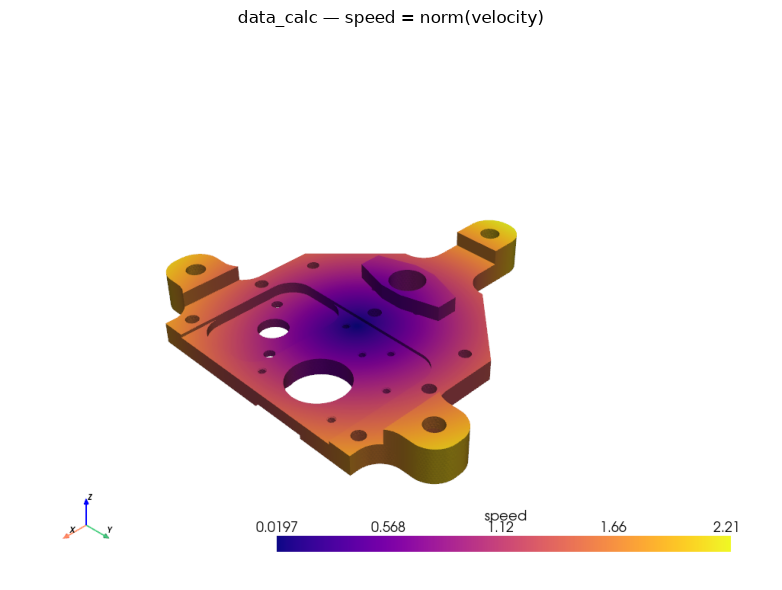

In [39]:
speed = mp.data_calc(surf_d, 'norm(velocity)', location='point', output='speed')
print('speed range:', round(speed.point_data['speed'].min(), 4),
      '->', round(speed.point_data['speed'].max(), 4))
render(speed, "data_calc — speed = norm(velocity)", scalars='speed', cmap='plasma',
       save='data_calc_speed')


### `point_data_to_cell_data` / `cell_data_to_point_data` — move between locations

Point→cell averages over each cell's own nodes; cell→point averages over the
incident cells, optionally weighted by cell area/volume. The round trip acts as
a smoothing pass, which is exactly what the two panels below show.


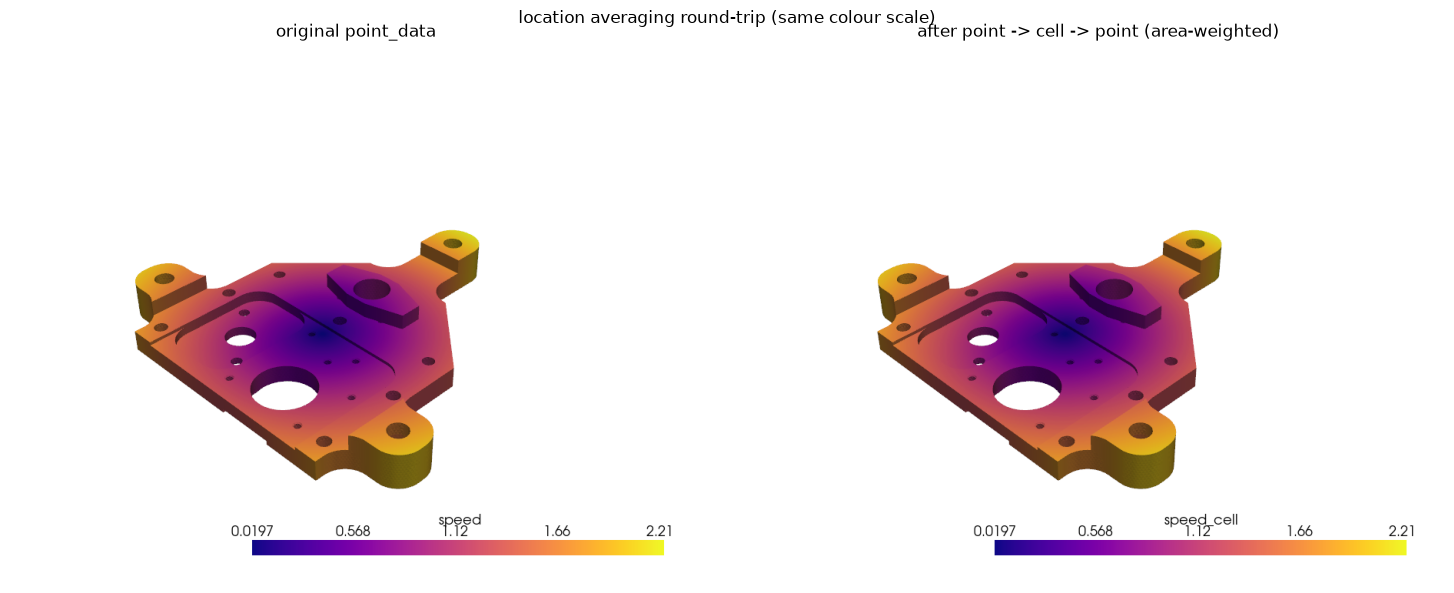

In [40]:
to_cell = mp.point_data_to_cell_data(speed, keys=['speed'], suffix='_cell')
back = mp.cell_data_to_point_data(to_cell, keys=['speed_cell'], weighted=True)

lo_s = float(speed.point_data['speed'].min())
hi_s = float(speed.point_data['speed'].max())

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (m, scal, ttl) in zip(axes, [
    (speed, 'speed', 'original point_data'),
    (back, 'speed_cell', 'after point -> cell -> point (area-weighted)'),
]):
    grid = to_pyvista(m)
    pl = pv.Plotter(off_screen=True, window_size=(900, 700))
    pl.add_mesh(grid, scalars=scal, cmap='plasma', clim=(lo_s, hi_s),
                show_edges=False)
    pl.view_isometric()
    img = pl.screenshot(return_img=True)
    pl.close()
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(ttl)
plt.suptitle('location averaging round-trip (same colour scale)')
plt.tight_layout()
save_fig('data_average_roundtrip')
plt.show()


### `data_condition` — clamp / normalize / standardize

Rescale values without touching the geometry. Normalizing to `[0, 1]` puts any
field on a common footing; note the colour bar below now spans exactly 0 to 1.


normalized range: 0.0 -> 1.0


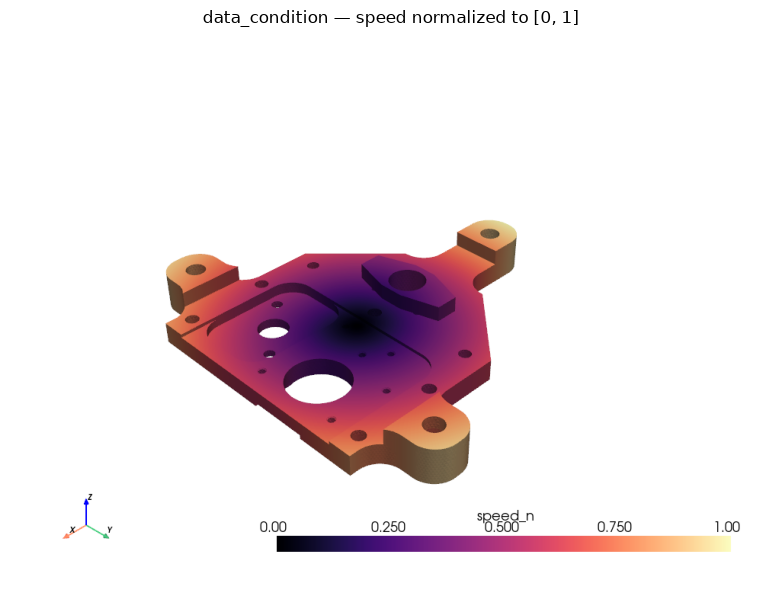

In [41]:
norm = mp.data_condition(speed, 'point', ['speed'], mode='normalize', suffix='_n')
got = norm.point_data['speed_n']
print('normalized range:', round(float(got.min()), 6), '->', round(float(got.max()), 6))
render(norm, 'data_condition — speed normalized to [0, 1]',
       scalars='speed_n', cmap='magma', clim=(0.0, 1.0), save='data_condition_normalize')


### `data_manage` — rename, drop, keep

Finally, tidy up: rename the derived field, drop the intermediate, and confirm
with `data_info` that only what we want is left — and that the geometry is
untouched throughout.


In [42]:
tidy = mp.data_rename(norm, 'point', 'speed_n', 'speed_normalized')
tidy = mp.data_drop(tidy, 'point', ['speed'])

show_data_info(tidy, 'after rename + drop:')

# Every data operation leaves points and connectivity bit-identical.
same_points = np.array_equal(surf_d.points, tidy.points)
same_cells = all(np.array_equal(np.asarray(a.data), np.asarray(b.data))
                 for a, b in zip(surf_d.cells, tidy.cells))
print()
print('geometry unchanged — points:', same_points, '| connectivity:', same_cells)


after rename + drop:
  location    name           dtype  comp  entries        min        max       mean
  point_data  height         f8        1    29151          0      0.382     0.1358
  point_data  speed_normalized f8        1    29151          0          1     0.5299
  point_data  velocity       f8        3    29151     -2.211      1.906 -1.424e-14

geometry unchanged — points: True | connectivity: True


## Selective reads: loading only what you need

`read()` normally decodes every data array. Two options narrow that, and
`read_metadata()` skips the heavy arrays entirely:

- `points_only=True` — geometry (points **and** connectivity), no data arrays
- `arrays=[...]` — only the named arrays (`[]` means none, `None` means all)

VTU, VTP, XDMF and Gmsh skip the unwanted array bodies outright; other formats
are read whole and filtered, so the answer is the same either way and only the
cost differs. `read_metadata()` reports which happened via
`fell_back_to_full_read`, so a summary never implies a saving that did not occur.

Below: the same file read three ways. A selective read is *lossy by request* --
the geometry is identical, only the data differs, which is exactly what the two
renders show.

In [43]:
import time

# A file with a data array worth skipping: colour by distance from the centroid.
sel_mesh = mp.read(EXAMPLE)
pts = np.asarray(sel_mesh.points, dtype=float)
sel_mesh.point_data['radius'] = np.linalg.norm(pts - pts.mean(axis=0), axis=1)

sel_path = os.path.join(tempfile.gettempdir(), 'selective_demo.vtu')
mp.write(sel_path, sel_mesh)


def timed(fn, repeats=5):
    """Best-of-N wall clock, to damp scheduler noise on a small file."""
    best = float('inf')
    for _ in range(repeats):
        t0 = time.perf_counter()
        out = fn()
        best = min(best, time.perf_counter() - t0)
    return out, best


full, t_full = timed(lambda: mp.read(sel_path))
bare, t_bare = timed(lambda: mp.read(sel_path, points_only=True))
meta, t_meta = timed(lambda: mp.read_metadata(sel_path))

print(f'full read       {t_full * 1e3:7.2f} ms   point_data={sorted(full.point_data)}')
print(f'points_only     {t_bare * 1e3:7.2f} ms   point_data={sorted(bare.point_data)}')
print(f'read_metadata   {t_meta * 1e3:7.2f} ms   '
      f"{meta['num_points']} points, {meta['num_cells']} cells, "
      f"arrays={meta['point_data_names']}")
print(f"summary was cheap: {not meta['fell_back_to_full_read']}")

# Geometry is bit-identical between the two reads -- only the data differs.
assert np.allclose(np.asarray(bare.points), np.asarray(full.points))
assert bare.point_data == {}
print('\nsame geometry, no data arrays:', bare.point_data == {})

full read         33.70 ms   point_data=['gmsh:dim_tags', 'radius']
points_only       23.08 ms   point_data=[]
read_metadata      3.68 ms   52282 points, 297811 cells, arrays=['gmsh:dim_tags', 'radius']
summary was cheap: True

same geometry, no data arrays: True


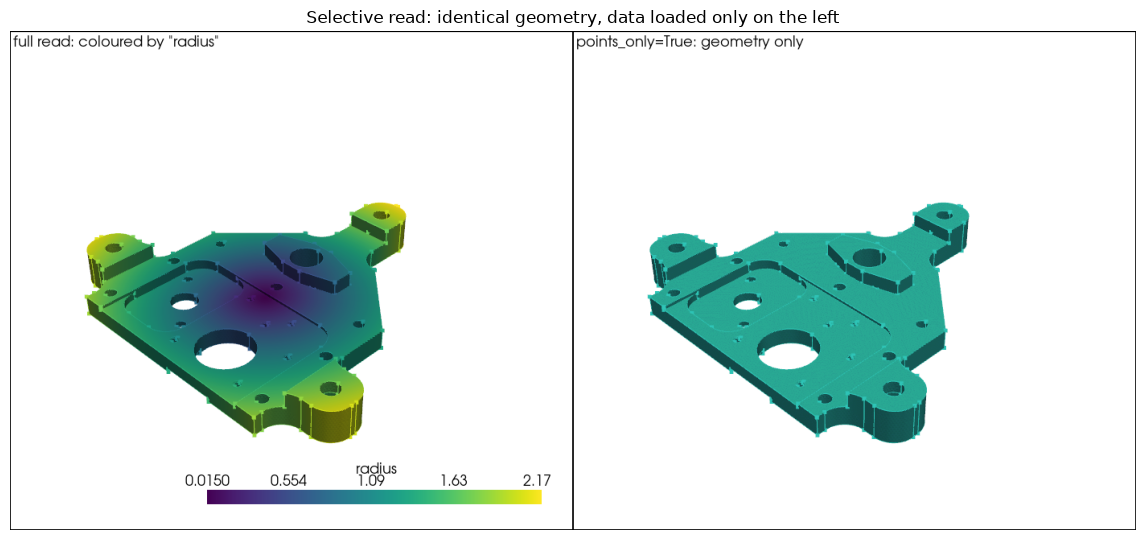

In [44]:
# Left: the full read, coloured by the data array it loaded.
# Right: the points_only read -- same geometry, nothing to colour by.
grid_full = to_pyvista(full)
grid_bare = to_pyvista(bare)

pl = pv.Plotter(off_screen=True, shape=(1, 2), window_size=(1400, 620))
pl.subplot(0, 0)
pl.add_text('full read: coloured by "radius"', font_size=10)
pl.add_mesh(grid_full, scalars='radius', cmap='viridis',
            scalar_bar_args={'title': 'radius'})
pl.subplot(0, 1)
pl.add_text('points_only=True: geometry only', font_size=10)
pl.add_mesh(grid_bare, color='#2ec4b6', show_edges=True,
            edge_color='#1f4e79', line_width=0.2)
pl.link_views()
pl.camera_position = 'iso'
img = pl.screenshot(return_img=True)
pl.close()

show(img, 'Selective read: identical geometry, data loaded only on the left',
     figsize=(13, 5.5), save='selective_read')

Reading the numbers honestly: on *this* file `points_only` saves only a little,
because `example.msh` is geometry-dominated -- its two point-data arrays are
small next to ~300k cells of connectivity, and connectivity is never skipped.
The saving scales with how much **data** a file carries, so a results file with
dozens of fields benefits far more than a bare mesh does.

`read_metadata()` is the consistent win (~7x here): it decodes neither the
coordinates nor the connectivity, only the per-cell type array. For XDMF it is
cheaper still -- every `DataItem` declares its shape, so the counts are exact
without touching any payload at all.